In [2]:
# ============================================================
# CELL 1 — DATA LOADING & CLEANING
# ============================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load ──────────────────────────────────────────────────
df = pd.read_csv('../data/merged_macro_cpi_2000_2026.csv')

# ── 2. Date parsing with fallback chain ──────────────────────
for fmt in ('%m/%d/%Y', '%Y-%m-%d', '%d/%m/%Y'):
    parsed = pd.to_datetime(df['date'], format=fmt, errors='coerce')
    if parsed.notna().all():
        df['date'] = parsed
        print(f"✔ Date parsed successfully with format: '{fmt}'")
        break
else:
    df['date'] = pd.to_datetime(df['date'], infer_datetime_format=True, errors='coerce')
    n_failed = df['date'].isna().sum()
    print(f"⚠ Fallback infer used — {n_failed} date(s) could not be parsed")

df = df.sort_values('date').reset_index(drop=True)

# ── 3. Column taxonomy ───────────────────────────────────────
MACRO_COLS = ['exchange_rate', 'oil_price', 'domestic_production', 'crude_oil_export']

CPI_HEADLINE = ['All Items']

CPI_CORE = [
    'All Items Less Farm Produce',
    'All Items Less Farm Produce And Energy'
]

CPI_COMPONENTS = [
    'Food', 'Transport', 'Clothing And Footwear',               # modelling targets
    'Imported Food',
    'Alcoholic Beverage Tobacco And Kola',
    'Housing Water Electricity Gas And Other  Fuel',
    'Furnishings And Household Equipment Maintenance',
    'Health', 'Communication', 'Recreation And Culture',
    'Education', 'Restaurant And Hotels',
    'Miscellaneous Goods And Services'
]

MODEL_TARGETS_RAW = ['Food', 'Transport', 'Clothing And Footwear']

ALL_EXPECTED = ['date'] + MACRO_COLS + CPI_HEADLINE + CPI_CORE + CPI_COMPONENTS
missing_cols  = [c for c in ALL_EXPECTED if c not in df.columns]
extra_cols    = [c for c in df.columns   if c not in ALL_EXPECTED]

# ── 4. Integrity checks ──────────────────────────────────────
checks = {
    "Shape"              : df.shape,
    "Date range"         : f"{df['date'].min().date()}  →  {df['date'].max().date()}",
    "Expected frequency" : "Monthly",
    "Missing columns"    : missing_cols if missing_cols else "None",
    "Extra columns"      : extra_cols   if extra_cols   else "None",
}

print("\n" + "═"*60)
print("  DATA INTEGRITY REPORT")
print("═"*60)
for k, v in checks.items():
    print(f"  {k:<22}: {v}")

# ── 5. Null audit ────────────────────────────────────────────
null_counts = df.isnull().sum()
print(f"\n  Null values          : {null_counts.sum()} total")
if null_counts.sum() > 0:
    print(null_counts[null_counts > 0].to_string())

# ── 6. Duplicate date check ──────────────────────────────────
dupe_dates = df['date'].duplicated().sum()
print(f"  Duplicate dates      : {dupe_dates}")
if dupe_dates > 0:
    df = df.drop_duplicates(subset=['date'])
    print(f"  → Dropped {dupe_dates} duplicate row(s)")

# ── 7. Frequency gap check ───────────────────────────────────
full_range  = pd.date_range(df['date'].min(), df['date'].max(), freq='MS')
actual_dates = pd.DatetimeIndex(df['date'])
gaps = full_range.difference(actual_dates)
print(f"  Missing months       : {len(gaps)}", end="")
print(f"  → {[str(g.date()) for g in gaps]}" if len(gaps) > 0 else "  (none)")

# ── 8. Scale/range sanity check ──────────────────────────────
print("\n" + "═"*60)
print("  COLUMN SCALE SUMMARY")
print("═"*60)
print(f"  {'Column':<52} {'Min':>10} {'Max':>10} {'Mean':>10}")
print("  " + "-"*84)
for col in MACRO_COLS + CPI_HEADLINE + MODEL_TARGETS_RAW:
    print(f"  {col:<52} {df[col].min():>10.2f} {df[col].max():>10.2f} {df[col].mean():>10.2f}")

# ── 9. Structural break flag (informational only) ────────────
covid_start  = pd.Timestamp('2020-03-01')
deval_start  = pd.Timestamp('2023-06-01')
pre_covid    = df[df['date'] < covid_start]
post_covid   = df[(df['date'] >= covid_start) & (df['date'] < deval_start)]
post_deval   = df[df['date'] >= deval_start]

print("\n" + "═"*60)
print("  STRUCTURAL BREAK PERIODS (row counts)")
print("═"*60)
print(f"  Pre-COVID  (< Mar 2020)                : {len(pre_covid):>4} rows")
print(f"  COVID→Devaluation (Mar 2020–May 2023)  : {len(post_covid):>4} rows")
print(f"  Post-Devaluation (≥ Jun 2023)          : {len(post_deval):>4} rows")

# ── 10. CPI index confirmation ───────────────────────────────
# CPI values are index numbers (not %, not raw prices).
# Base period is identifiable by where values ≈ 100.
base_window = df[(df['All Items'] >= 95) & (df['All Items'] <= 105)]['date']
print(f"\n  CPI 'All Items' ≈ 100 during: {base_window.min().strftime('%b %Y')} – {base_window.max().strftime('%b %Y')}")
print("  Confirms: CPI columns are index values. MoM % changes will be derived in next cell.")

print("\n" + "═"*60)
print("  ✔  Data loading and cleaning complete.")
print(f"     Final shape : {df.shape[0]} rows × {df.shape[1]} columns")
print("═"*60)

✔ Date parsed successfully with format: '%m/%d/%Y'

════════════════════════════════════════════════════════════
  DATA INTEGRITY REPORT
════════════════════════════════════════════════════════════
  Shape                 : (313, 21)
  Date range            : 2000-02-01  →  2026-02-01
  Expected frequency    : Monthly
  Missing columns       : None
  Extra columns         : None

  Null values          : 0 total
  Duplicate dates      : 0
  Missing months       : 0  (none)

════════════════════════════════════════════════════════════
  COLUMN SCALE SUMMARY
════════════════════════════════════════════════════════════
  Column                                                      Min        Max       Mean
  ------------------------------------------------------------------------------------
  exchange_rate                                             99.87    1670.47     326.36
  oil_price                                                 14.28     138.74      75.15
  domestic_production    

════════════════════════════════════════════════════════════════════════
  SECTION 1 — DESCRIPTIVE STATISTICS
════════════════════════════════════════════════════════════════════════

  Raw Index / Macro Levels:
          exchange_rate  oil_price  domestic_production  crude_oil_export     Food  Transport  Clothing And Footwear
Mean            326.356     75.150                2.067             1.617   40.661     47.467                 48.710
Median          157.310     66.680                2.160             1.710   25.778     35.792                 35.924
Std Dev         380.946     22.344                0.467             0.467   36.513     35.565                 34.401
Min              99.870     14.280                0.940             0.490    5.323      8.886                 12.946
Max            1670.470    138.740                2.880             2.430  142.209    139.436                130.310
Skewness          2.505      0.637               -0.624            -0.624    1.152    

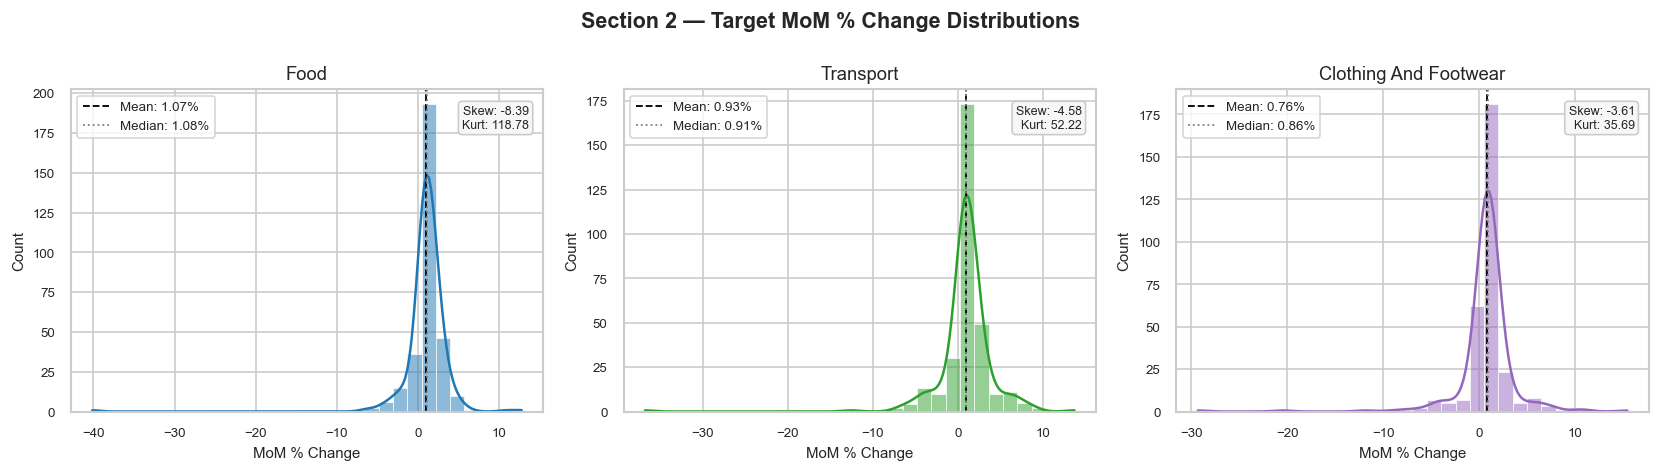

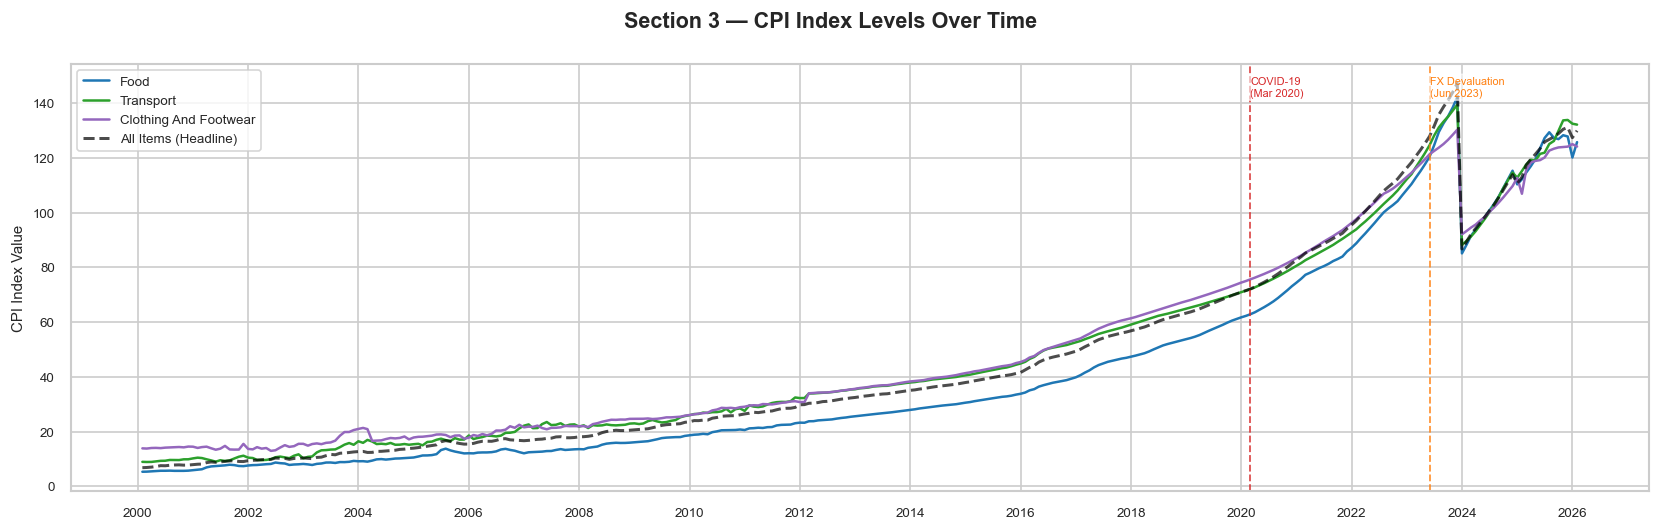

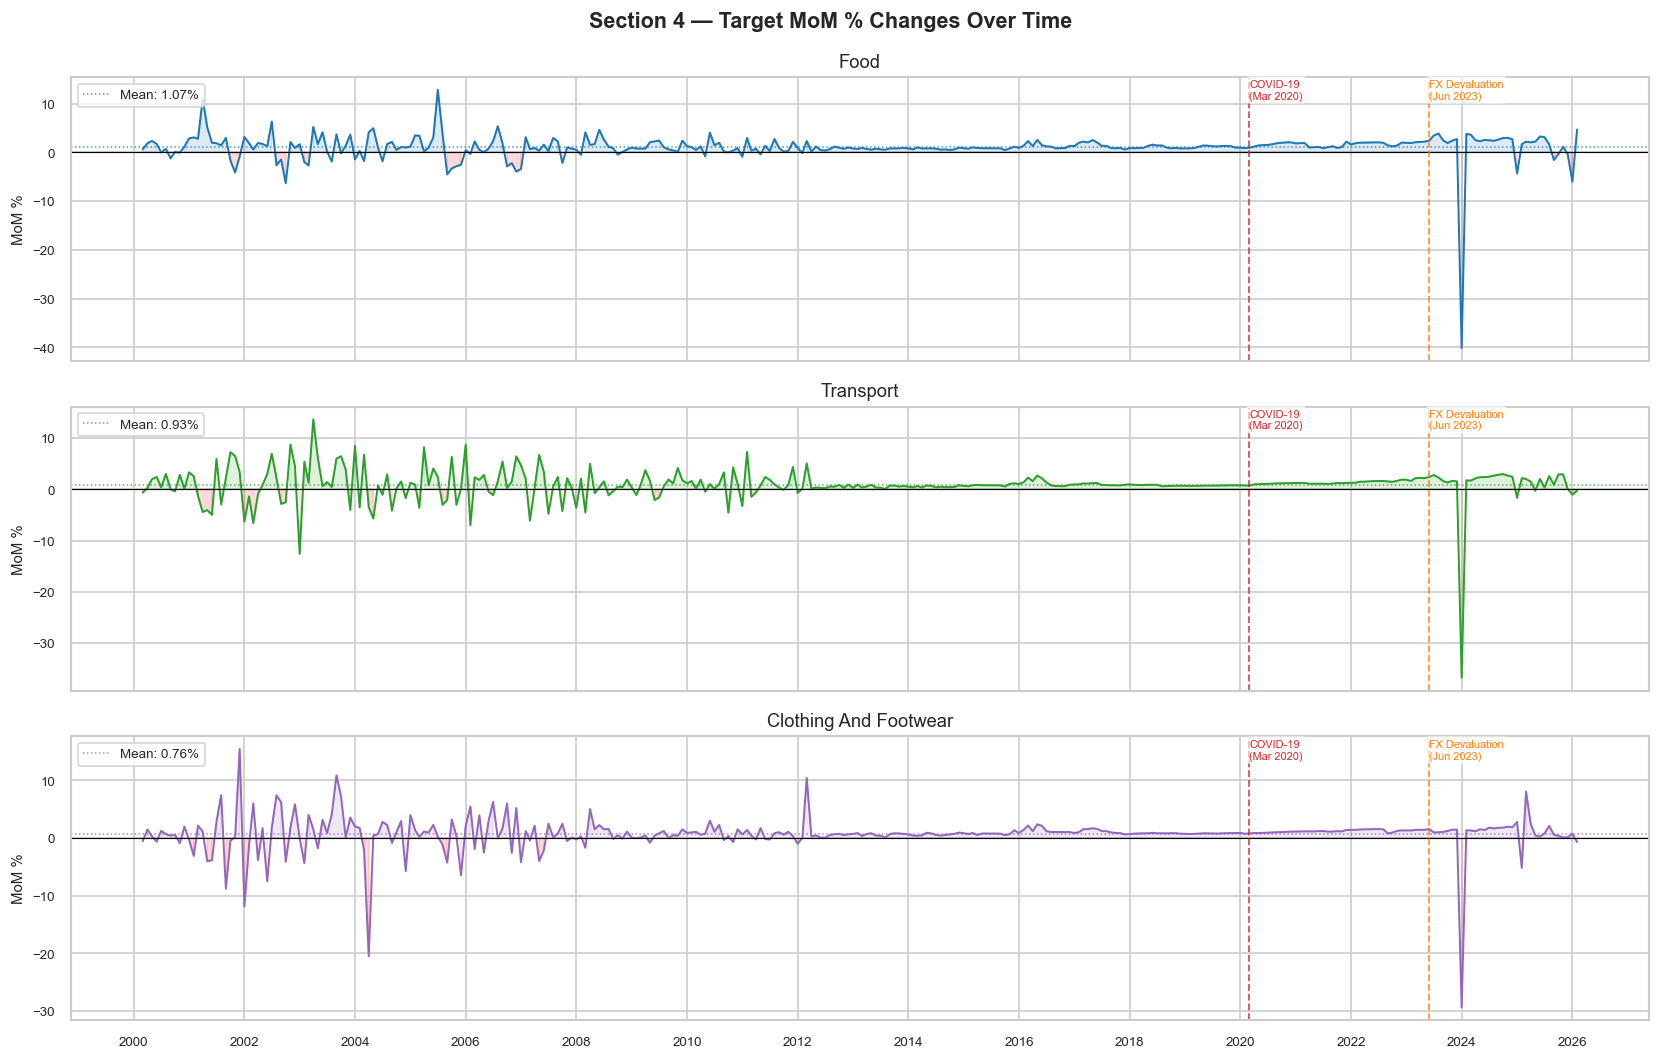

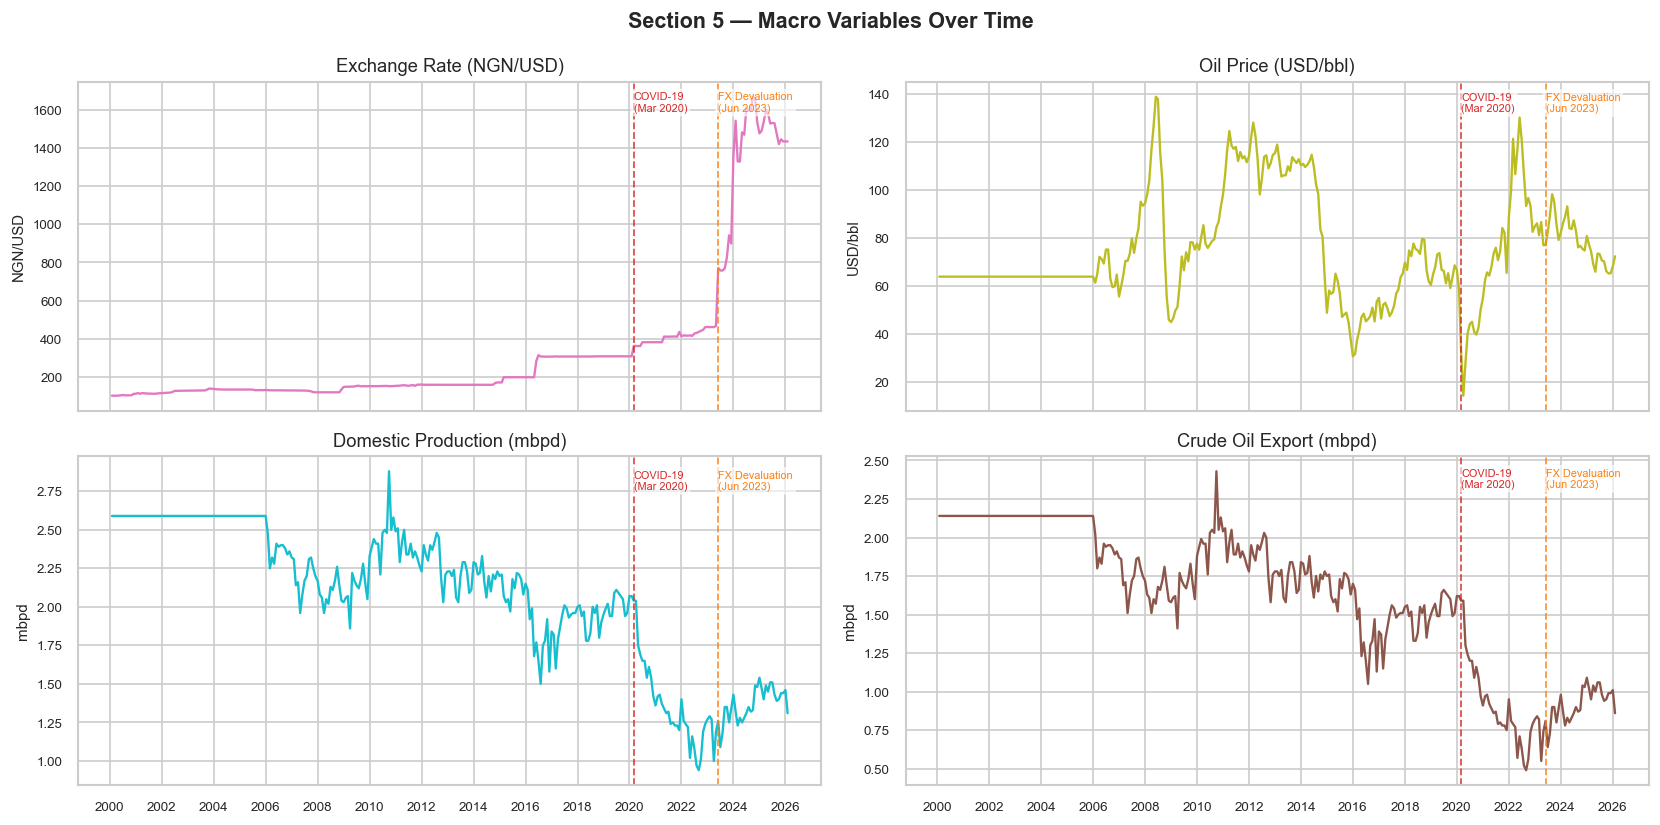

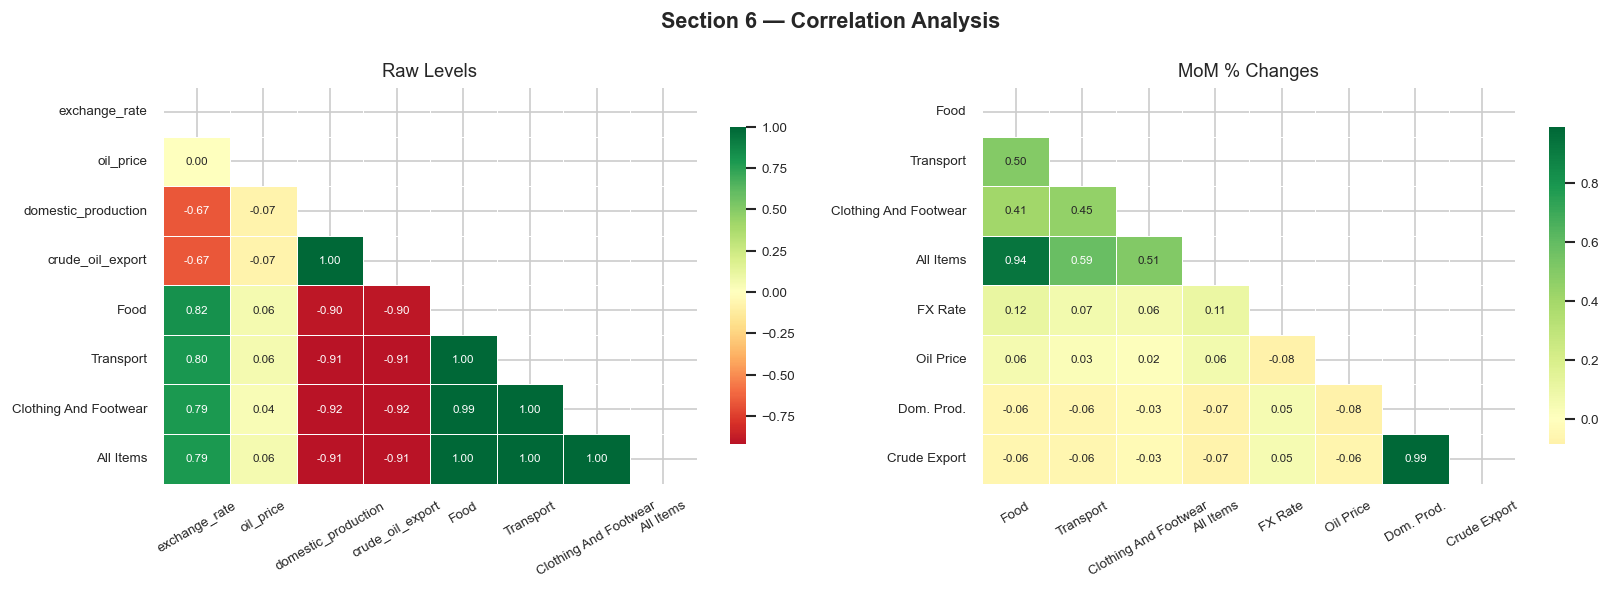

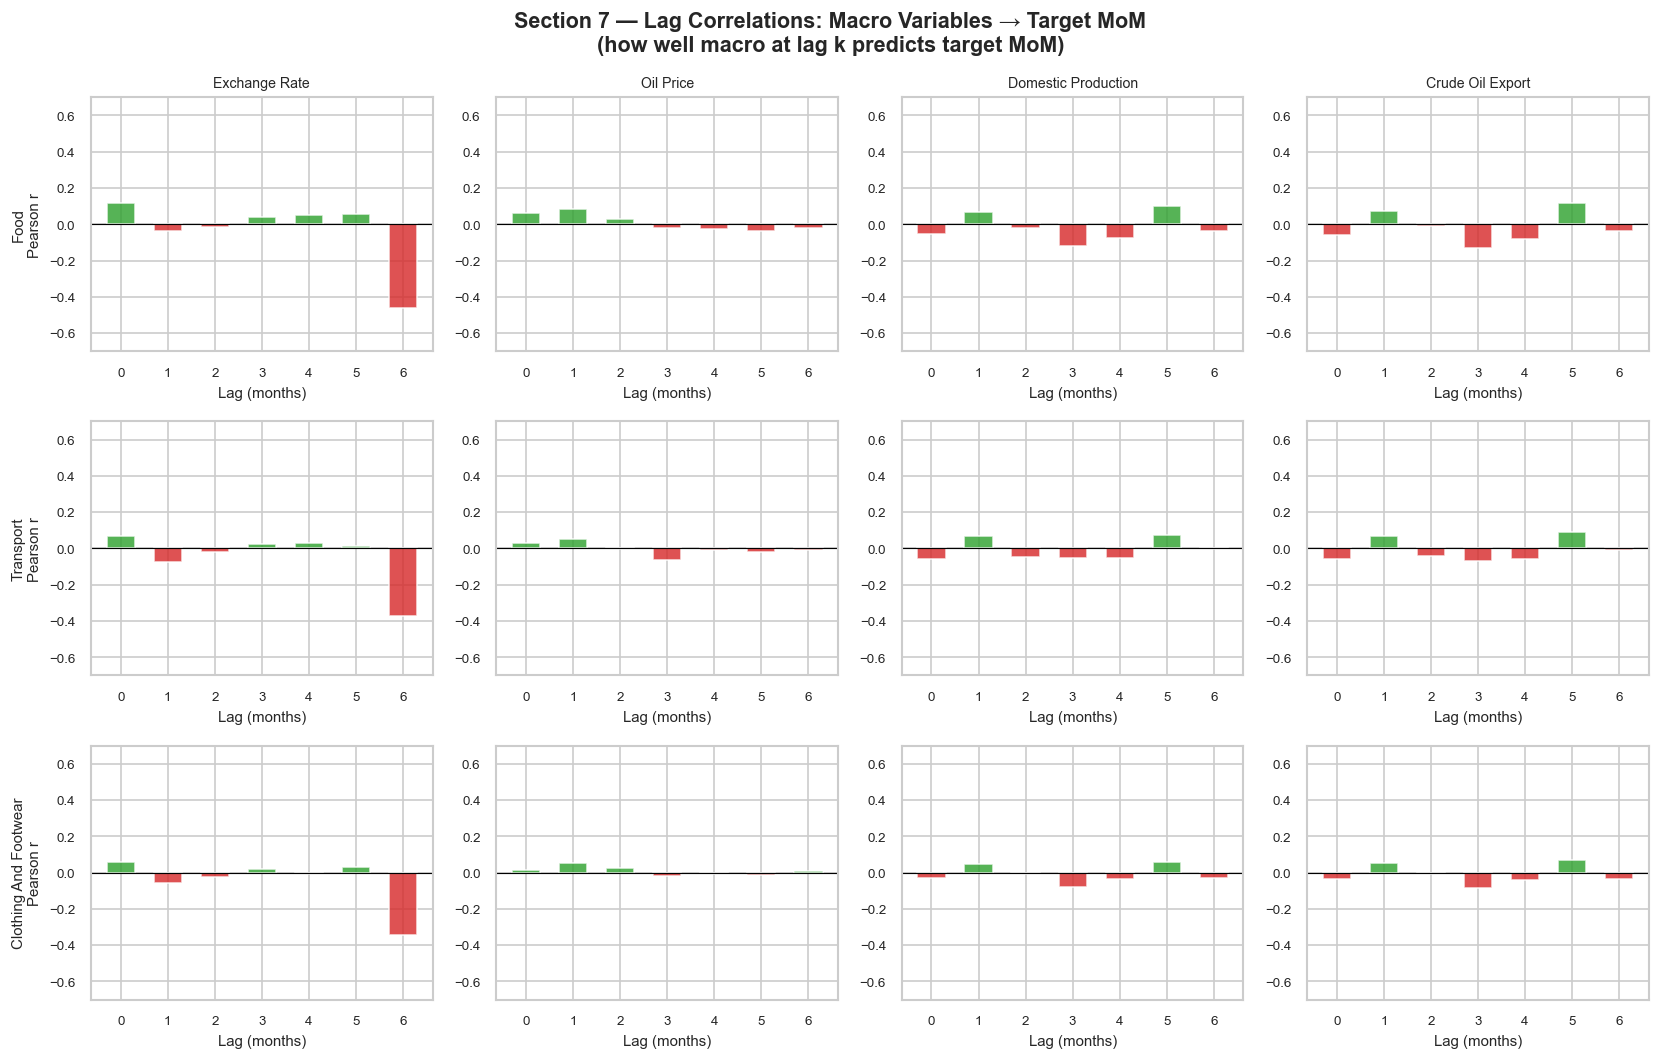

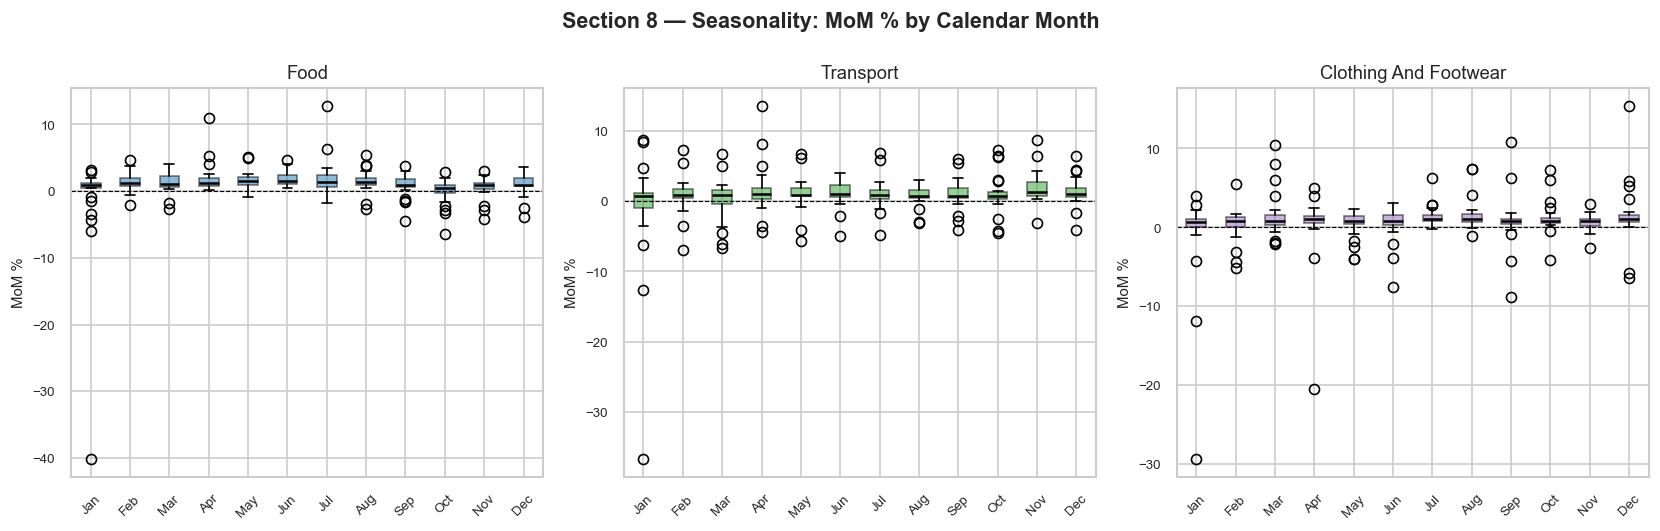


════════════════════════════════════════════════════════════════════════
  SECTION 9 — OUTLIER DETECTION (|Z-score| > 3)
════════════════════════════════════════════════════════════════════════

  Food (3 outlier(s)):
    Apr 2001 : 10.97%
    Jul 2005 : 12.82%
    Jan 2024 : -40.15%

  Transport (3 outlier(s)):
    Jan 2003 : -12.61%
    Apr 2003 : 13.65%
    Jan 2024 : -36.75%

  Clothing And Footwear (7 outlier(s)):
    Sep 2001 : -8.80%
    Dec 2001 : 15.43%
    Jan 2002 : -11.87%
    Sep 2003 : 10.88%
    Apr 2004 : -20.49%
    Mar 2012 : 10.40%
    Jan 2024 : -29.34%


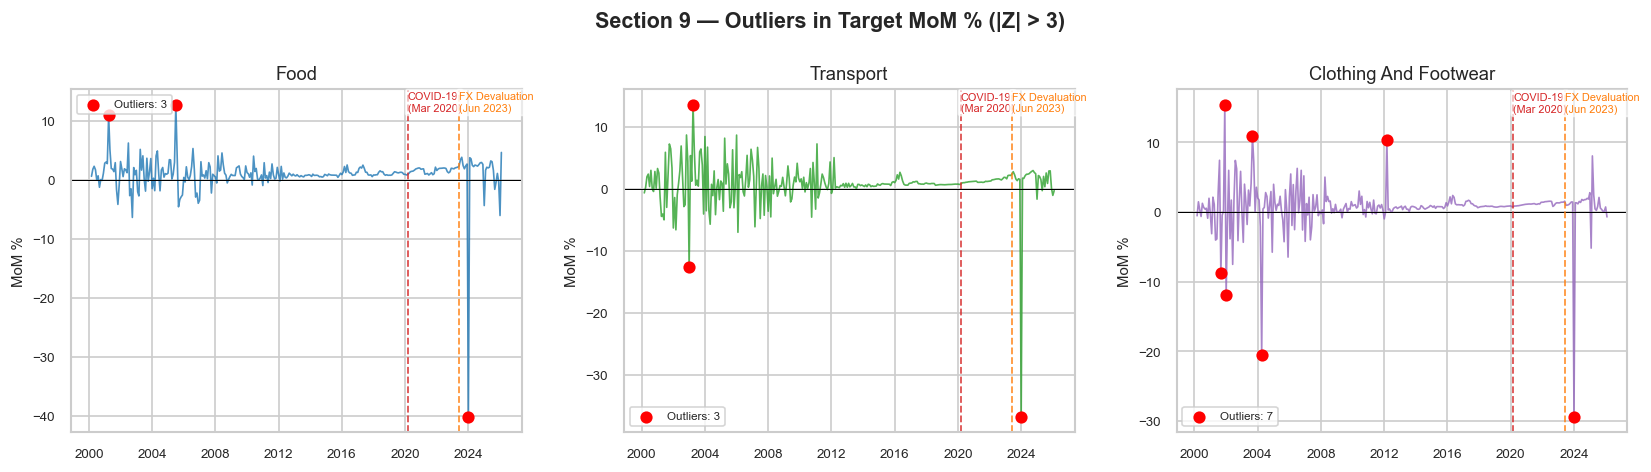

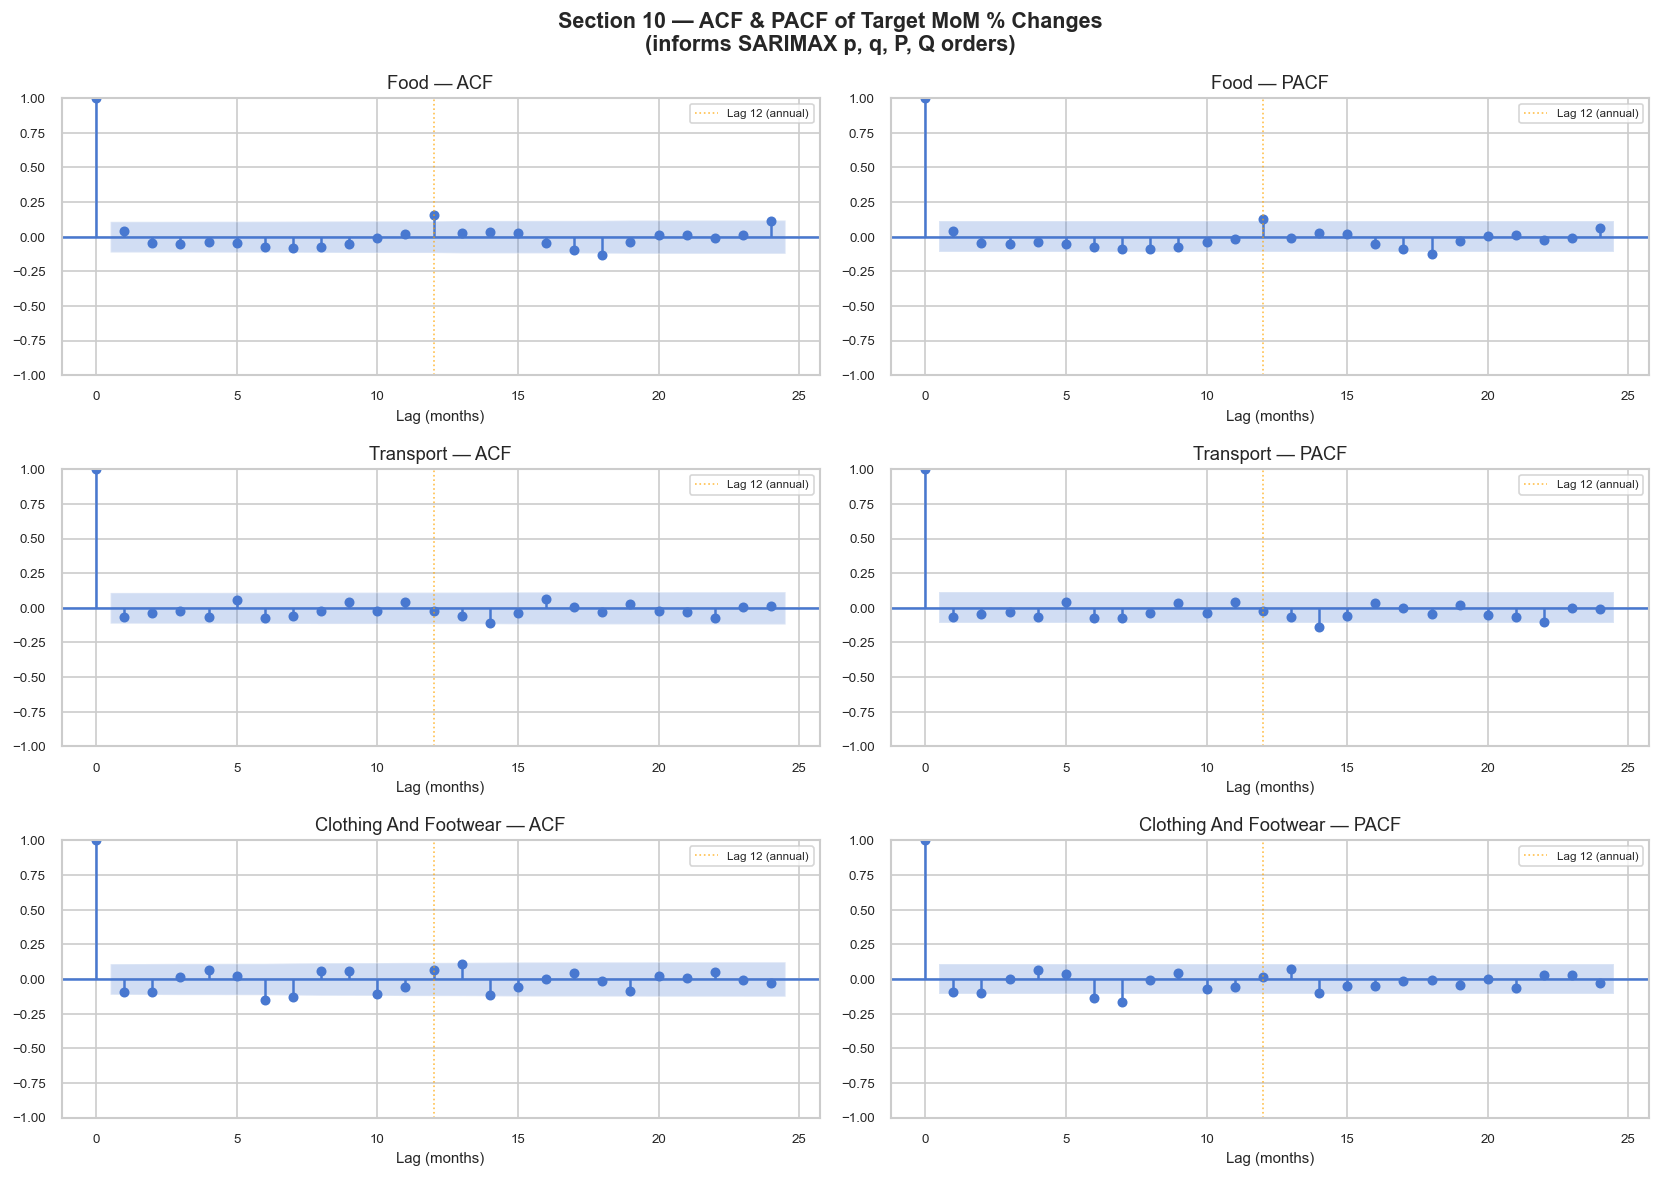


════════════════════════════════════════════════════════════════════════
  ✔  EDA complete.
════════════════════════════════════════════════════════════════════════


In [3]:
# ============================================================
# CELL 2 — EXPLORATORY DATA ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.titlesize'  : 11,
    'axes.labelsize'  : 9,
    'xtick.labelsize' : 8,
    'ytick.labelsize' : 8,
    'legend.fontsize' : 8,
    'figure.titlesize': 13,
})

# ── Structural break reference lines (reused across plots) ───
BREAKS = {
    'COVID-19\n(Mar 2020)'   : pd.Timestamp('2020-03-01'),
    'FX Devaluation\n(Jun 2023)' : pd.Timestamp('2023-06-01'),
}
BREAK_COLORS = ['#d62728', '#ff7f0e']

def add_breaks(ax):
    for (label, ts), color in zip(BREAKS.items(), BREAK_COLORS):
        ax.axvline(ts, color=color, linestyle='--', linewidth=1.1, alpha=0.8)
        ax.text(ts, ax.get_ylim()[1] * 0.97, label,
                color=color, fontsize=6.5, va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))

TARGET_COLS  = ['Food', 'Transport', 'Clothing And Footwear']
TARGET_COLORS = ['#1f77b4', '#2ca02c', '#9467bd']
MACRO_COLS   = ['exchange_rate', 'oil_price', 'domestic_production', 'crude_oil_export']
MACRO_LABELS = ['Exchange Rate (NGN/USD)', 'Oil Price (USD/bbl)',
                'Domestic Production (mbpd)', 'Crude Oil Export (mbpd)']

# ── Compute MoM % changes (EDA only — not persisted to df) ───
mom = pd.DataFrame({'date': df['date']})
for col in TARGET_COLS + ['All Items']:
    mom[col + '_mom'] = df[col].pct_change() * 100
mom = mom.dropna().reset_index(drop=True)

TARGET_MOM = [c + '_mom' for c in TARGET_COLS]
HEADLINE_MOM = 'All Items_mom'


# ════════════════════════════════════════════════════════════
# SECTION 1 — DESCRIPTIVE STATISTICS
# ════════════════════════════════════════════════════════════
print("═"*72)
print("  SECTION 1 — DESCRIPTIVE STATISTICS")
print("═"*72)

stat_cols = MACRO_COLS + TARGET_COLS
stats_df  = df[stat_cols].agg(['mean','median','std','min','max',
                                 lambda x: x.skew(), lambda x: x.kurt()])
stats_df.index = ['Mean','Median','Std Dev','Min','Max','Skewness','Kurtosis']
print("\n  Raw Index / Macro Levels:")
print(stats_df.round(3).to_string())

mom_stat_cols = TARGET_MOM + [HEADLINE_MOM]
mom_stats = mom[mom_stat_cols].agg(['mean','median','std','min','max',
                                      lambda x: x.skew(), lambda x: x.kurt()])
mom_stats.index = ['Mean','Median','Std Dev','Min','Max','Skewness','Kurtosis']
mom_stats.columns = [c.replace('_mom','') for c in mom_stats.columns]
print("\n  MoM % Change (targets):")
print(mom_stats.round(3).to_string())


# ════════════════════════════════════════════════════════════
# SECTION 2 — TARGET MoM DISTRIBUTIONS
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Section 2 — Target MoM % Change Distributions', fontweight='bold')

for ax, col, color, label in zip(axes, TARGET_MOM, TARGET_COLORS, TARGET_COLS):
    series = mom[col].dropna()
    sns.histplot(series, kde=True, ax=ax, color=color, bins=30,
                 edgecolor='white', linewidth=0.4)
    ax.axvline(series.mean(),   color='black', linestyle='--', linewidth=1.1,
               label=f'Mean: {series.mean():.2f}%')
    ax.axvline(series.median(), color='grey',  linestyle=':',  linewidth=1.1,
               label=f'Median: {series.median():.2f}%')
    ax.set_title(label)
    ax.set_xlabel('MoM % Change')
    ax.set_ylabel('Count')
    sk = series.skew()
    ku = series.kurt()
    ax.text(0.97, 0.95, f'Skew: {sk:.2f}\nKurt: {ku:.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.3', fc='#f7f7f7', ec='#cccccc'))
    ax.legend()

plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════════
# SECTION 3 — CPI INDEX LEVELS OVER TIME
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 4.5))
fig.suptitle('Section 3 — CPI Index Levels Over Time', fontweight='bold')

for col, color, label in zip(TARGET_COLS, TARGET_COLORS, TARGET_COLS):
    ax.plot(df['date'], df[col], color=color, linewidth=1.5, label=col)
ax.plot(df['date'], df['All Items'], color='black', linewidth=1.8,
        linestyle='--', label='All Items (Headline)', alpha=0.7)

add_breaks(ax)
ax.set_ylabel('CPI Index Value')
ax.set_xlabel('')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════════
# SECTION 4 — TARGET MoM % CHANGES OVER TIME
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Section 4 — Target MoM % Changes Over Time', fontweight='bold')

for ax, col, color, label in zip(axes, TARGET_MOM, TARGET_COLORS, TARGET_COLS):
    ax.plot(mom['date'], mom[col], color=color, linewidth=1.2)
    ax.fill_between(mom['date'], mom[col], 0,
                    where=(mom[col] >= 0), alpha=0.15, color=color)
    ax.fill_between(mom['date'], mom[col], 0,
                    where=(mom[col] < 0),  alpha=0.15, color='red')
    ax.axhline(0, color='black', linewidth=0.7)
    ax.axhline(mom[col].mean(), color=color, linewidth=0.9,
               linestyle=':', alpha=0.8, label=f'Mean: {mom[col].mean():.2f}%')
    add_breaks(ax)
    ax.set_ylabel('MoM %')
    ax.set_title(label)
    ax.legend(loc='upper left')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════════
# SECTION 5 — MACRO VARIABLES OVER TIME
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
fig.suptitle('Section 5 — Macro Variables Over Time', fontweight='bold')
axes = axes.flatten()

macro_colors = ['#e377c2', '#bcbd22', '#17becf', '#8c564b']
for ax, col, label, color in zip(axes, MACRO_COLS, MACRO_LABELS, macro_colors):
    ax.plot(df['date'], df[col], color=color, linewidth=1.4)
    add_breaks(ax)
    ax.set_title(label)
    ax.set_ylabel(label.split('(')[-1].replace(')','').strip())

for ax in axes[-2:]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════════
# SECTION 6 — CORRELATION HEATMAP
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 6 — Correlation Analysis', fontweight='bold')

# 6a: Raw levels
corr_cols  = MACRO_COLS + TARGET_COLS + ['All Items']
corr_level = df[corr_cols].corr()
mask       = np.triu(np.ones_like(corr_level, dtype=bool))
sns.heatmap(corr_level, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[0], linewidths=0.5,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 7})
axes[0].set_title('Raw Levels')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# 6b: MoM changes
mom_corr_df = mom[TARGET_MOM + [HEADLINE_MOM]].copy()
for col in MACRO_COLS:
    mom_corr_df[col] = df[col].pct_change().values[:len(mom_corr_df)]
corr_mom = mom_corr_df.corr()
mask2    = np.triu(np.ones_like(corr_mom, dtype=bool))
labels   = [c.replace('_mom','').replace('exchange_rate','FX Rate')
              .replace('oil_price','Oil Price')
              .replace('domestic_production','Dom. Prod.')
              .replace('crude_oil_export','Crude Export') for c in corr_mom.columns]
sns.heatmap(corr_mom, mask=mask2, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[1], linewidths=0.5,
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 7})
axes[1].set_title('MoM % Changes')
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════════
# SECTION 7 — LAG CORRELATION (Macro → Target MoM)
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle('Section 7 — Lag Correlations: Macro Variables → Target MoM\n'
             '(how well macro at lag k predicts target MoM)', fontweight='bold')

macro_mom = {col: df[col].pct_change() for col in MACRO_COLS}
LAGS = range(0, 7)

for row_i, (target_mom_col, target_label) in enumerate(zip(TARGET_MOM, TARGET_COLS)):
    for col_i, (macro_col, macro_label) in enumerate(zip(MACRO_COLS, MACRO_LABELS)):
        ax = axes[row_i][col_i]
        lag_corrs = []
        for lag in LAGS:
            shifted = macro_mom[macro_col].shift(lag).values[:len(mom)]
            target  = mom[target_mom_col].values
            valid   = ~np.isnan(shifted) & ~np.isnan(target)
            r, _    = stats.pearsonr(shifted[valid], target[valid])
            lag_corrs.append(r)

        bar_colors = ['#2ca02c' if c >= 0 else '#d62728' for c in lag_corrs]
        ax.bar(list(LAGS), lag_corrs, color=bar_colors, width=0.6, alpha=0.8)
        ax.axhline(0, color='black', linewidth=0.7)
        ax.set_ylim(-0.7, 0.7)
        ax.set_xticks(list(LAGS))
        ax.set_xlabel('Lag (months)')
        if col_i == 0:
            ax.set_ylabel(f'{target_label}\nPearson r')
        if row_i == 0:
            ax.set_title(macro_label.split('(')[0].strip(), fontsize=8.5)

plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════════
# SECTION 8 — SEASONALITY (Monthly Boxplots)
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle('Section 8 — Seasonality: MoM % by Calendar Month', fontweight='bold')

mom['month']     = mom['date'].dt.month
MONTH_LABELS     = ['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']

for ax, col, color, label in zip(axes, TARGET_MOM, TARGET_COLORS, TARGET_COLS):
    monthly_data = [mom[mom['month'] == m][col].dropna().values for m in range(1, 13)]
    bp = ax.boxplot(monthly_data, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=1.5))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_LABELS, rotation=45)
    ax.set_title(label)
    ax.set_ylabel('MoM %')

plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════════
# SECTION 9 — OUTLIER DETECTION (Z-Score)
# ════════════════════════════════════════════════════════════
print("\n" + "═"*72)
print("  SECTION 9 — OUTLIER DETECTION (|Z-score| > 3)")
print("═"*72)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Section 9 — Outliers in Target MoM % (|Z| > 3)', fontweight='bold')

for ax, col, color, label in zip(axes, TARGET_MOM, TARGET_COLORS, TARGET_COLS):
    series  = mom[col].dropna()
    z       = np.abs(stats.zscore(series))
    outlier_mask = z > 3
    n_out   = outlier_mask.sum()

    ax.plot(mom['date'][:len(series)], series, color=color, linewidth=1.0, alpha=0.8)
    ax.scatter(mom['date'][:len(series)][outlier_mask],
               series[outlier_mask], color='red', zorder=5, s=40, label=f'Outliers: {n_out}')
    ax.axhline(0, color='black', linewidth=0.6)
    add_breaks(ax)
    ax.set_title(label)
    ax.set_ylabel('MoM %')
    ax.legend(fontsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))

    # Print outlier dates
    outlier_dates = mom['date'][:len(series)][outlier_mask]
    outlier_vals  = series[outlier_mask]
    if n_out > 0:
        print(f"\n  {label} ({n_out} outlier(s)):")
        for d, v in zip(outlier_dates, outlier_vals):
            print(f"    {d.strftime('%b %Y')} : {v:.2f}%")
    else:
        print(f"\n  {label}: No outliers detected")

plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════════
# SECTION 10 — ACF / PACF
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Section 10 — ACF & PACF of Target MoM % Changes\n'
             '(informs SARIMAX p, q, P, Q orders)', fontweight='bold')

for row_i, (col, label) in enumerate(zip(TARGET_MOM, TARGET_COLS)):
    series = mom[col].dropna()
    plot_acf( series, lags=24, ax=axes[row_i][0], title=f'{label} — ACF',  alpha=0.05)
    plot_pacf(series, lags=24, ax=axes[row_i][1], title=f'{label} — PACF', alpha=0.05,
              method='ywm')
    for ax in axes[row_i]:
        ax.axvline(12, color='orange', linestyle=':', linewidth=1.0, alpha=0.7,
                   label='Lag 12 (annual)')
        ax.legend(fontsize=7)
        ax.set_xlabel('Lag (months)')

plt.tight_layout()
plt.show()

print("\n" + "═"*72)
print("  ✔  EDA complete.")
print("═"*72)

═════════════════════════════════════════════════════════════════
  DATA SPLIT REPORT  (70 / 10 / 20 — time-ordered)
═════════════════════════════════════════════════════════════════
  Split       Rows  From          To             Share
  -------------------------------------------------------
  Train        219  Feb 2000      Apr 2018       70.0%
  Validation    31  May 2018      Nov 2020        9.9%
  Test          63  Dec 2020      Feb 2026       20.1%
  -------------------------------------------------------
  Total        313
═════════════════════════════════════════════════════════════════

  Split boundaries:
    Train  ends : April 2018  (idx 218)
    Val    ends : November 2020  (idx 249)
    Test   ends : February 2026  (idx 312)

  Purpose of each split:
    Train      → fit SARIMAX, Random Forest, LSTM base learners
    Validation → LSTM early stopping; XGBoost meta-learner tuning
    Test       → final held-out evaluation only (never seen during training)
════════════════

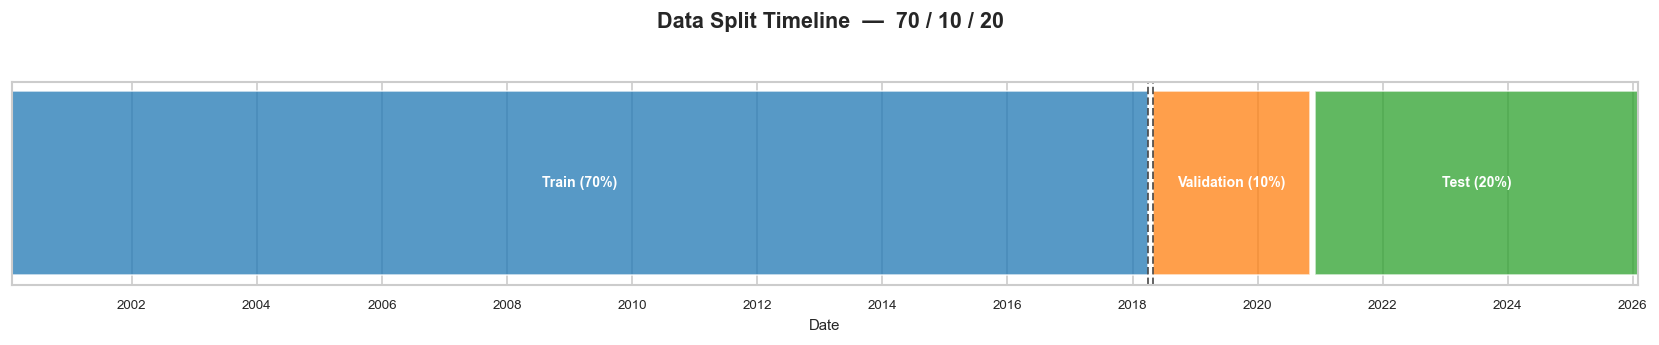

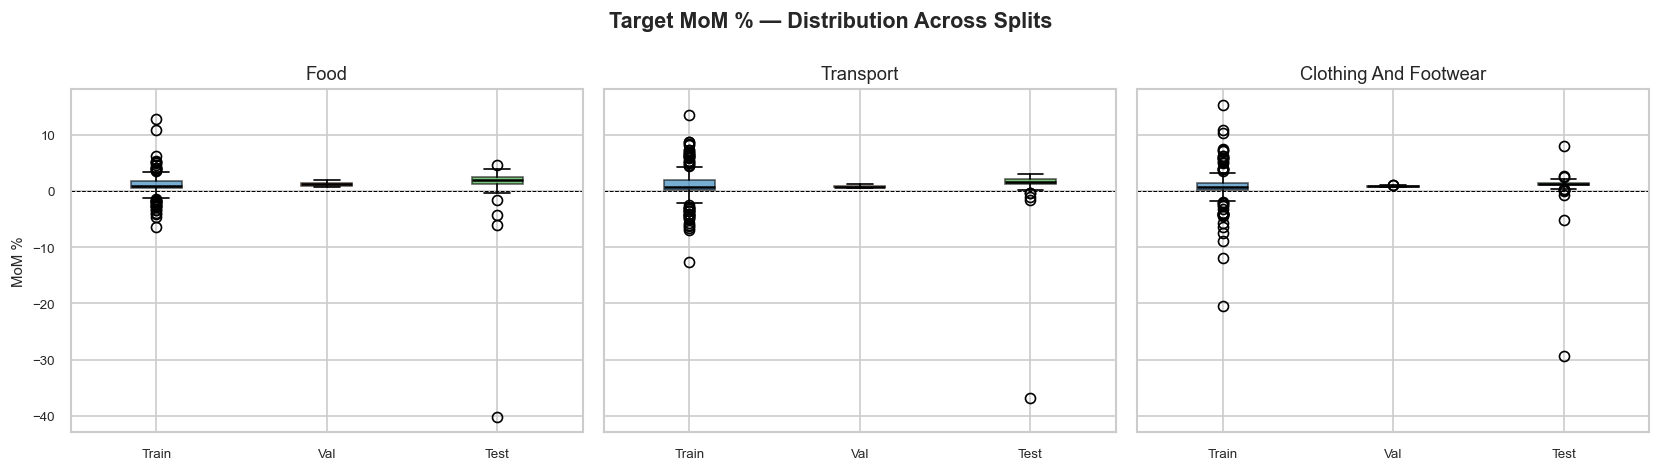


  ✔  Splits ready:  train_df, val_df, test_df


In [4]:
# ============================================================
# CELL 3 — TIME-BASED DATA SPLITTING (70 / 10 / 20)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# ── Compute split indices ─────────────────────────────────────
n         = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.80)

train_df = df.iloc[:train_end].copy().reset_index(drop=True)
val_df   = df.iloc[train_end:val_end].copy().reset_index(drop=True)
test_df  = df.iloc[val_end:].copy().reset_index(drop=True)

train_end_date = train_df['date'].max()
val_end_date   = val_df['date'].max()
test_end_date  = test_df['date'].max()

# ── Console report ────────────────────────────────────────────
print("═"*65)
print("  DATA SPLIT REPORT  (70 / 10 / 20 — time-ordered)")
print("═"*65)
print(f"  {'Split':<10} {'Rows':>5}  {'From':<12}  {'To':<12}  {'Share':>6}")
print("  " + "-"*55)
print(f"  {'Train':<10} {len(train_df):>5}  "
      f"{train_df['date'].min().strftime('%b %Y'):<12}  "
      f"{train_end_date.strftime('%b %Y'):<12}  "
      f"{len(train_df)/n*100:>5.1f}%")
print(f"  {'Validation':<10} {len(val_df):>5}  "
      f"{val_df['date'].min().strftime('%b %Y'):<12}  "
      f"{val_end_date.strftime('%b %Y'):<12}  "
      f"{len(val_df)/n*100:>5.1f}%")
print(f"  {'Test':<10} {len(test_df):>5}  "
      f"{test_df['date'].min().strftime('%b %Y'):<12}  "
      f"{test_end_date.strftime('%b %Y'):<12}  "
      f"{len(test_df)/n*100:>5.1f}%")
print("  " + "-"*55)
print(f"  {'Total':<10} {n:>5}")
print("═"*65)
print()
print("  Split boundaries:")
print(f"    Train  ends : {train_end_date.strftime('%B %Y')}  (idx {train_end - 1})")
print(f"    Val    ends : {val_end_date.strftime('%B %Y')}  (idx {val_end - 1})")
print(f"    Test   ends : {test_end_date.strftime('%B %Y')}  (idx {n - 1})")
print()
print("  Purpose of each split:")
print("    Train      → fit SARIMAX, Random Forest, LSTM base learners")
print("    Validation → LSTM early stopping; XGBoost meta-learner tuning")
print("    Test       → final held-out evaluation only (never seen during training)")
print("═"*65)

# ── Target distribution check across splits ──────────────────
TARGET_COLS = ['Food', 'Transport', 'Clothing And Footwear']

print()
print("  TARGET MoM % — MEAN ACROSS SPLITS")
print("  (computed here for sanity check; persisted in Feature Engineering cell)")
print("  " + "-"*65)
print(f"  {'Target':<28} {'Train':>8} {'Val':>8} {'Test':>8}  {'Drift?':>8}")
print("  " + "-"*65)

for col in TARGET_COLS:
    tr_mom = train_df[col].pct_change().dropna() * 100
    va_mom = val_df[col].pct_change().dropna() * 100
    te_mom = test_df[col].pct_change().dropna() * 100
    drift  = abs(te_mom.mean() - tr_mom.mean()) > 1.5
    flag   = "⚠ yes" if drift else "ok"
    print(f"  {col:<28} {tr_mom.mean():>7.3f}% {va_mom.mean():>7.3f}% {te_mom.mean():>7.3f}%  {flag:>8}")

print("  " + "-"*65)
print("  ⚠ flag = test mean deviates > 1.5 pp from train mean")
print("═"*65)

# ── Visual timeline ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 2.8))
fig.suptitle('Data Split Timeline  —  70 / 10 / 20', fontweight='bold', y=1.02)

split_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
splits       = [
    (train_df['date'].min(), train_end_date,  'Train (70%)',      split_colors[0]),
    (val_df['date'].min(),   val_end_date,    'Validation (10%)', split_colors[1]),
    (test_df['date'].min(),  test_end_date,   'Test (20%)',       split_colors[2]),
]

for start, end, label, color in splits:
    ax.barh(0, (end - start).days, left=start, height=0.5,
            color=color, alpha=0.75, label=label)
    mid = start + (end - start) / 2
    ax.text(mid, 0, label, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white')

# Boundary lines
for ts in [train_end_date, val_df['date'].min()]:
    ax.axvline(ts, color='black', linewidth=1.2, linestyle='--', alpha=0.6)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.set_yticks([])
ax.set_xlabel('Date')
ax.set_xlim(df['date'].min(), df['date'].max())
plt.tight_layout()
plt.show()

# ── CPI MoM across splits (visual drift check) ───────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle('Target MoM % — Distribution Across Splits', fontweight='bold')

TARGET_COLORS = ['#1f77b4', '#2ca02c', '#9467bd']
split_labels  = ['Train', 'Val', 'Test']
split_dfs     = [train_df, val_df, test_df]

for ax, col, color in zip(axes, TARGET_COLS, TARGET_COLORS):
    data_by_split = []
    for sdf in split_dfs:
        mom_vals = sdf[col].pct_change().dropna() * 100
        data_by_split.append(mom_vals.values)

    bp = ax.boxplot(data_by_split, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=1.5),
                    tick_labels=split_labels)
    for patch, c in zip(bp['boxes'], split_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.6)

    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title(col)
    ax.set_ylabel('MoM %' if ax == axes[0] else '')

plt.tight_layout()
plt.show()

print("\n  ✔  Splits ready:  train_df, val_df, test_df")

In [5]:
# ============================================================
# CELL 4 — FEATURE ENGINEERING
# ============================================================
# Design rules:
#   1. create_features() applied to each split independently
#      — no information crosses split boundaries
#   2. All lag/rolling ops use shift(≥1) — no same-period leakage
#   3. ffill only within each split
#   4. dropna() only trims the head of each split (lag warm-up)
# ============================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Column groups (defined in Cell 1, redeclared for clarity) ─
TARGET_COLS  = ['Food', 'Transport', 'Clothing And Footwear']
TARGET_NAMES = ['food_mom', 'transport_mom', 'clothing_mom']
MACRO_COLS   = ['exchange_rate', 'oil_price', 'domestic_production', 'crude_oil_export']


def create_features(data: pd.DataFrame) -> pd.DataFrame:
    """
    Build the full feature matrix for one split.
    Input  : a raw split dataframe (date + all original columns)
    Output : enriched dataframe with MoM targets + all features,
             NaN head rows dropped
    """
    df = data.copy()

    # ── Step 1: MoM % change targets ─────────────────────────
    for raw_col, mom_col in zip(TARGET_COLS, TARGET_NAMES):
        df[mom_col] = df[raw_col].pct_change() * 100

    df['all_items_mom'] = df['All Items'].pct_change() * 100

    # ── Step 2: Lagged features ───────────────────────────────
    # Macro vars: lags 1, 2, 3
    for col in MACRO_COLS:
        for lag in [1, 2, 3]:
            df[f'{col}_lag_{lag}'] = df[col].shift(lag)

    # Headline MoM: lags 1, 2, 3
    for lag in [1, 2, 3]:
        df[f'all_items_mom_lag_{lag}'] = df['all_items_mom'].shift(lag)

    # Target MoMs: lags 1, 2, 3, 6
    # ACF/PACF: Food sig. at lag 12, Clothing at 6 & 7 — lag 6 covers both
    for col in TARGET_NAMES:
        for lag in [1, 2, 3, 6]:
            df[f'{col}_lag_{lag}'] = df[col].shift(lag)

    # ── Step 3: Rolling statistics ────────────────────────────
    # Macro vars + headline: 3-month and 6-month windows
    for col in MACRO_COLS + ['all_items_mom']:
        for window in [3, 6]:
            df[f'{col}_roll_mean_{window}'] = (
                df[col].shift(1).rolling(window=window).mean()
            )
            df[f'{col}_roll_std_{window}'] = (
                df[col].shift(1).rolling(window=window).std()
            )

    # Target MoMs: 3-month rolling mean (momentum signal)
    for col in TARGET_NAMES:
        df[f'{col}_roll_mean_3'] = (
            df[col].shift(1).rolling(window=3).mean()
        )

    # ── Step 4: Derived macro features ───────────────────────
    # Oil × FX interaction — imported inflation channel
    df['oil_fx_interaction'] = df['oil_price'] * df['exchange_rate']
    df['oil_fx_interaction_lag_1'] = df['oil_fx_interaction'].shift(1)

    # Crude export / domestic production ratio — supply pressure
    df['crude_export_prod_ratio'] = (
        df['crude_oil_export'] / df['domestic_production'].replace(0, np.nan)
    )
    df['crude_export_prod_ratio_lag_1'] = df['crude_export_prod_ratio'].shift(1)

    # YoY % change on exchange rate and oil price (12-month lag)
    df['exchange_rate_yoy'] = df['exchange_rate'].pct_change(12) * 100
    df['oil_price_yoy']     = df['oil_price'].pct_change(12) * 100

    # ── Step 5: Cyclical month encoding ──────────────────────
    df['month']     = df['date'].dt.month
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # ── Step 6: Structural break dummies ─────────────────────
    df['post_covid']        = (df['date'] >= '2020-03-01').astype(int)
    df['post_2023_deval']   = (df['date'] >= '2023-06-01').astype(int)
    df['post_2024_rebase']  = (df['date'] >= '2024-01-01').astype(int)
    # Jan 2024 spike flagged as outlier in EDA (CPI base year rebasing)

    # ── Step 7: Clean up ─────────────────────────────────────
    # Forward-fill any isolated NaNs within this split only
    df = df.ffill()

    # Drop only the head rows where lags cannot be computed
    # (max lag used = 12 for YoY, but YoY only applies to macro levels
    #  which are non-missing; actual NaN head from target lags = 6 rows)
    df = df.dropna().reset_index(drop=True)

    return df


# ── Apply to each split ───────────────────────────────────────
train_df = create_features(train_df)
val_df   = create_features(val_df)
test_df  = create_features(test_df)

# ── Define X / y ─────────────────────────────────────────────
DROP_COLS    = ['date'] + TARGET_COLS + ['All Items'] + [
    'All Items Less Farm Produce',
    'All Items Less Farm Produce And Energy',
    'Imported Food',
    'Alcoholic Beverage Tobacco And Kola',
    'Housing Water Electricity Gas And Other  Fuel',
    'Furnishings And Household Equipment Maintenance',
    'Health', 'Communication', 'Recreation And Culture',
    'Education', 'Restaurant And Hotels',
    'Miscellaneous Goods And Services',
    'all_items_mom',           # derived intermediate; not a predictor
    'month',                   # encoded as sin/cos already
]

feature_cols = [c for c in train_df.columns
                if c not in DROP_COLS + TARGET_NAMES]

X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET_NAMES].copy()

X_val   = val_df[feature_cols].copy()
y_val   = val_df[TARGET_NAMES].copy()

X_test  = test_df[feature_cols].copy()
y_test  = test_df[TARGET_NAMES].copy()

# ── Verification report ───────────────────────────────────────
print("═"*65)
print("  FEATURE ENGINEERING REPORT")
print("═"*65)
print(f"\n  {'Split':<10} {'X shape':>14}  {'y shape':>12}  {'Date range'}")
print("  " + "-"*58)
for name, xdf, ydf, sdf in [
    ('Train', X_train, y_train, train_df),
    ('Val',   X_val,   y_val,   val_df),
    ('Test',  X_test,  y_test,  test_df),
]:
    dr = (f"{sdf['date'].min().strftime('%b %Y')} → "
          f"{sdf['date'].max().strftime('%b %Y')}")
    print(f"  {name:<10} {str(xdf.shape):>14}  {str(ydf.shape):>12}  {dr}")

print(f"\n  Total features : {len(feature_cols)}")

# Feature group summary
groups = {
    'Macro raw'             : [c for c in feature_cols if c in MACRO_COLS],
    'Macro lags'            : [c for c in feature_cols if '_lag_' in c and
                                any(m in c for m in MACRO_COLS)],
    'Macro rolling'         : [c for c in feature_cols if 'roll_' in c and
                                any(m in c for m in MACRO_COLS)],
    'Headline MoM lags'     : [c for c in feature_cols if 'all_items_mom' in c],
    'Target MoM lags'       : [c for c in feature_cols if any(
                                t in c for t in TARGET_NAMES) and '_lag_' in c],
    'Target MoM rolling'    : [c for c in feature_cols if any(
                                t in c for t in TARGET_NAMES) and 'roll_' in c],
    'Derived macro'         : [c for c in feature_cols if c in [
                                'oil_fx_interaction', 'oil_fx_interaction_lag_1',
                                'crude_export_prod_ratio',
                                'crude_export_prod_ratio_lag_1',
                                'exchange_rate_yoy', 'oil_price_yoy']],
    'Cyclical encoding'     : [c for c in feature_cols if 'month_' in c],
    'Structural dummies'    : [c for c in feature_cols if 'post_' in c],
}

print()
print(f"  {'Feature group':<28} {'Count':>5}  Features")
print("  " + "-"*60)
for group, cols in groups.items():
    preview = ', '.join(cols[:3]) + (' ...' if len(cols) > 3 else '')
    print(f"  {group:<28} {len(cols):>5}  {preview}")

# Null check
total_nulls = X_train.isnull().sum().sum()
print(f"\n  Null values in X_train : {total_nulls}")
print(f"  Null values in X_val   : {X_val.isnull().sum().sum()}")
print(f"  Null values in X_test  : {X_test.isnull().sum().sum()}")

# Leakage check — confirm no raw target levels in features
raw_target_in_features = [c for c in feature_cols if c in TARGET_COLS]
print(f"\n  Raw target cols in features : "
      f"{'NONE ✔' if not raw_target_in_features else raw_target_in_features}")

print("\n" + "═"*65)
print("  ✔  Feature engineering complete.")
print(f"     X_train: {X_train.shape}  |  X_val: {X_val.shape}  "
      f"|  X_test: {X_test.shape}")
print("═"*65)

═════════════════════════════════════════════════════════════════
  FEATURE ENGINEERING REPORT
═════════════════════════════════════════════════════════════════

  Split             X shape       y shape  Date range
  ----------------------------------------------------------
  Train           (207, 65)      (207, 3)  Feb 2001 → Apr 2018
  Val              (19, 65)       (19, 3)  May 2019 → Nov 2020
  Test             (51, 65)       (51, 3)  Dec 2021 → Feb 2026

  Total features : 65

  Feature group                Count  Features
  ------------------------------------------------------------
  Macro raw                        4  exchange_rate, oil_price, domestic_production ...
  Macro lags                      12  exchange_rate_lag_1, exchange_rate_lag_2, exchange_rate_lag_3 ...
  Macro rolling                   16  exchange_rate_roll_mean_3, exchange_rate_roll_std_3, exchange_rate_roll_mean_6 ...
  Headline MoM lags                7  all_items_mom_lag_1, all_items_mom_lag_2, all_ite

═════════════════════════════════════════════════════════════════
  SARIMAX — AIC Grid Search & Fitting
═════════════════════════════════════════════════════════════════

  ▸ Food
    Best ARIMA order    : (2, 1, 1)
    Best seasonal order : (0, 1, 1, 12)
    Best AIC            : 772.62
    Model saved         : ../models/sarimax_food_mom.pkl

    Top-5 AIC candidates:
      ARIMA(2, 1, 1) x SARIMA(0, 1, 1, 12)  AIC=772.62 ◄ best
      ARIMA(1, 1, 1) x SARIMA(1, 1, 1, 12)  AIC=774.17
      ARIMA(2, 1, 1) x SARIMA(1, 1, 1, 12)  AIC=783.46
      ARIMA(2, 1, 2) x SARIMA(0, 1, 1, 12)  AIC=801.25
      ARIMA(2, 1, 2) x SARIMA(1, 1, 0, 12)  AIC=812.55

    Residual Diagnostics (train fit):
    Ljung-Box lag=10 : stat=34.299, p=0.0002 ⚠ autocorr.
    Ljung-Box lag=20 : stat=52.182, p=0.0001 ⚠ autocorr.
    Jarque-Bera      : stat=127.574, p=0.0000 ⚠ non-normal
      skew=0.242, excess kurtosis=3.555

  ▸ Transport
    Best ARIMA order    : (2, 1, 1)
    Best seasonal order : (1, 1, 1, 12)
  

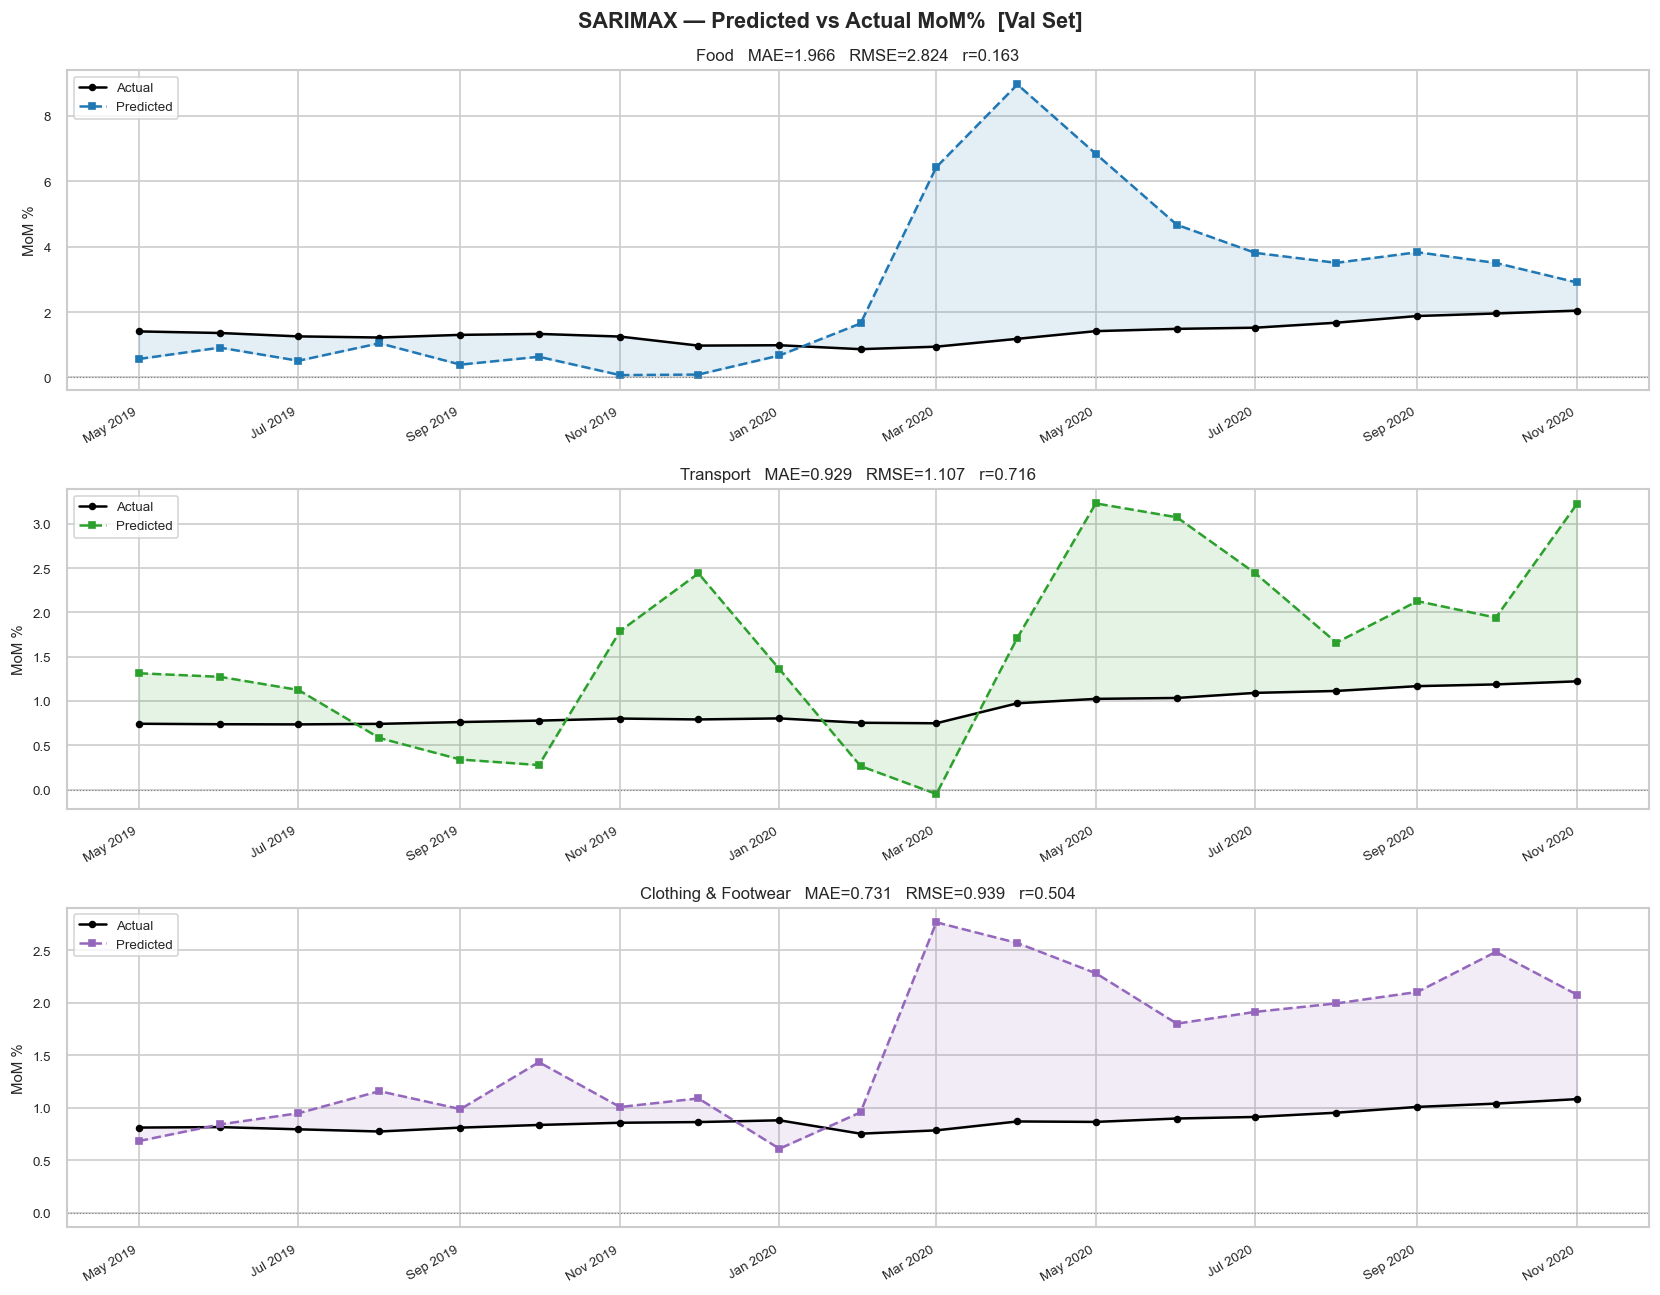

  Plot saved : ../outputs/sarimax_pred_vs_actual_val.png
  CSV  saved : ../outputs/sarimax_pred_vs_actual_val.csv


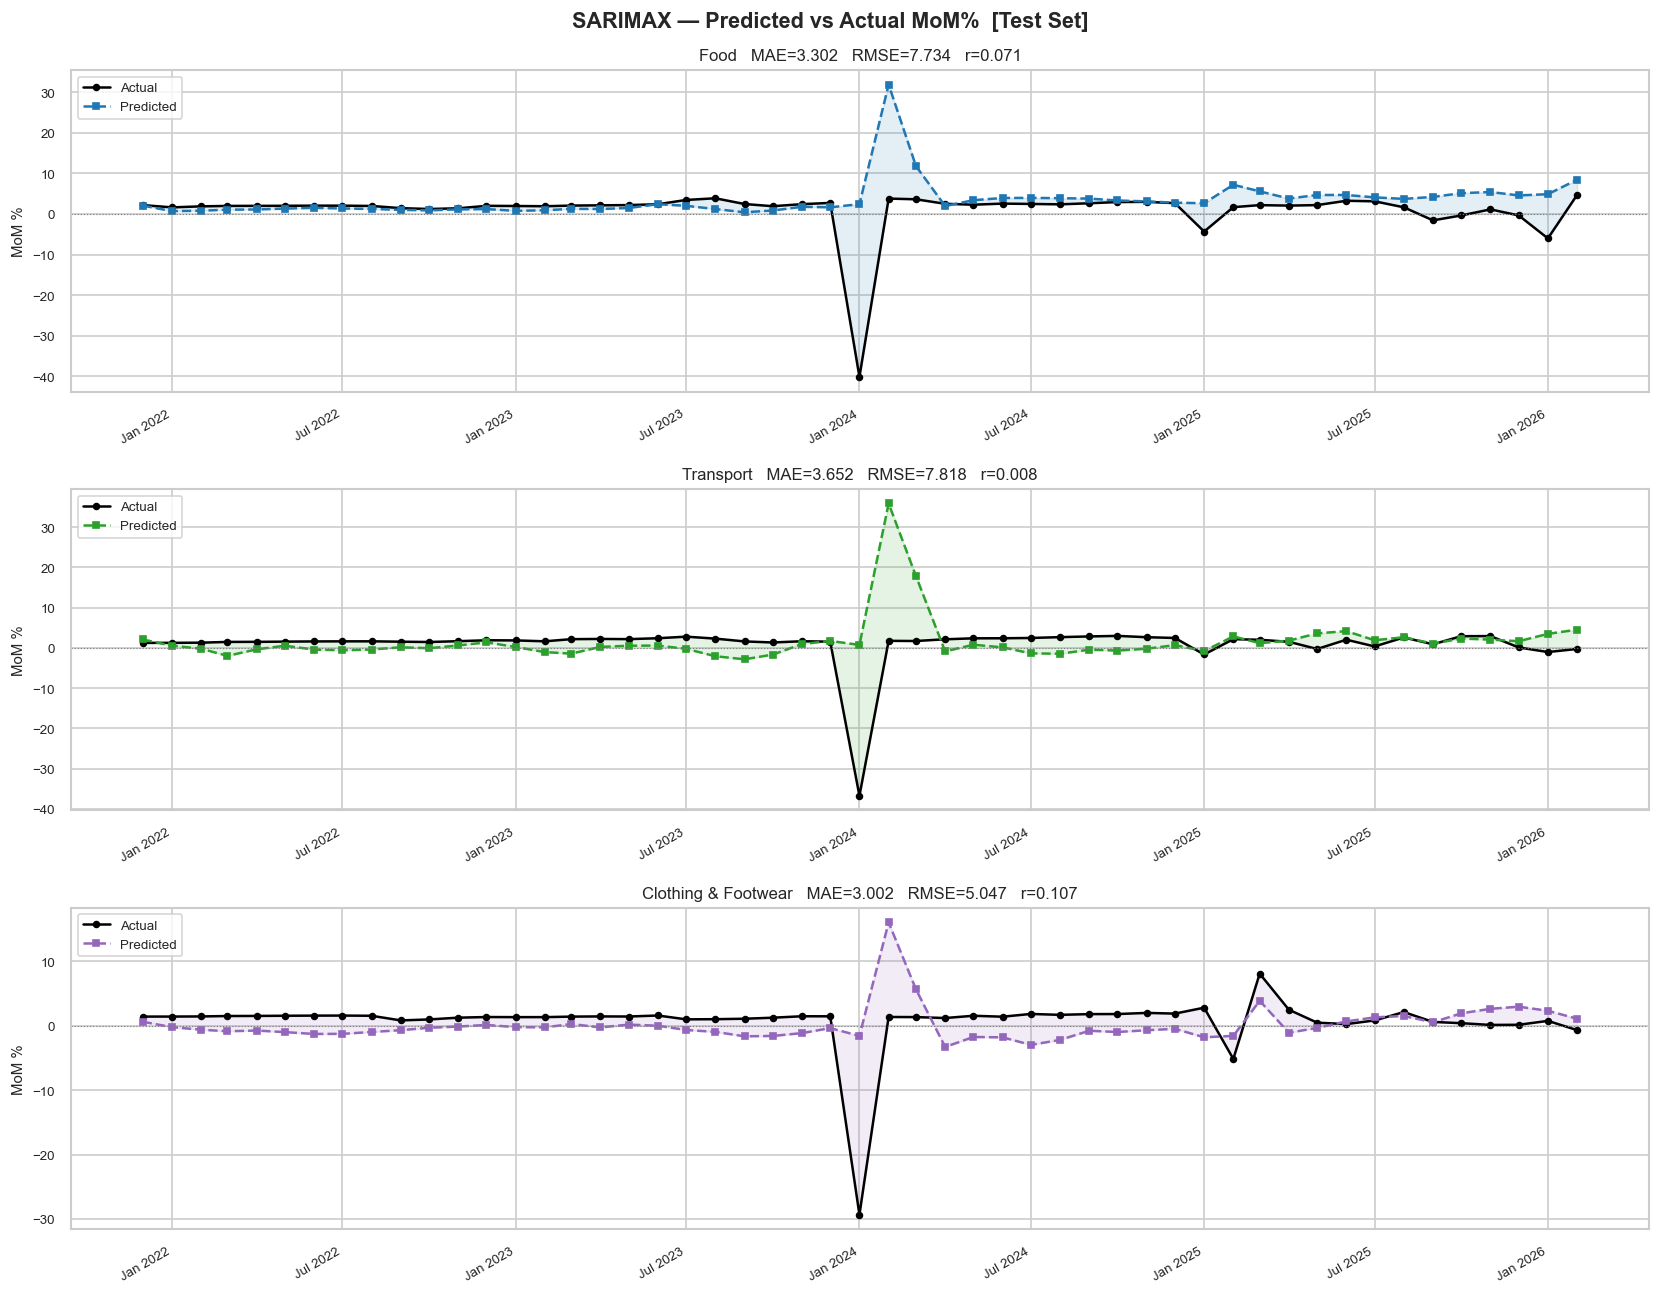

  Plot saved : ../outputs/sarimax_pred_vs_actual_test.png
  CSV  saved : ../outputs/sarimax_pred_vs_actual_test.csv

═════════════════════════════════════════════════════════════════
  OUTPUT 2 — Residual Diagnostics
═════════════════════════════════════════════════════════════════
  Diagnostics CSV saved : ../outputs/sarimax_residual_diagnostics.csv

             target best_order     aic  lb_pval_lag10  jb_pval  lb_lag10_pass  jb_pass
               Food  (2, 1, 1) 772.621         0.0002      0.0          False    False
          Transport  (2, 1, 1) 944.497         0.0000      0.0          False    False
Clothing & Footwear  (1, 1, 1) 937.294         0.0000      0.0          False    False


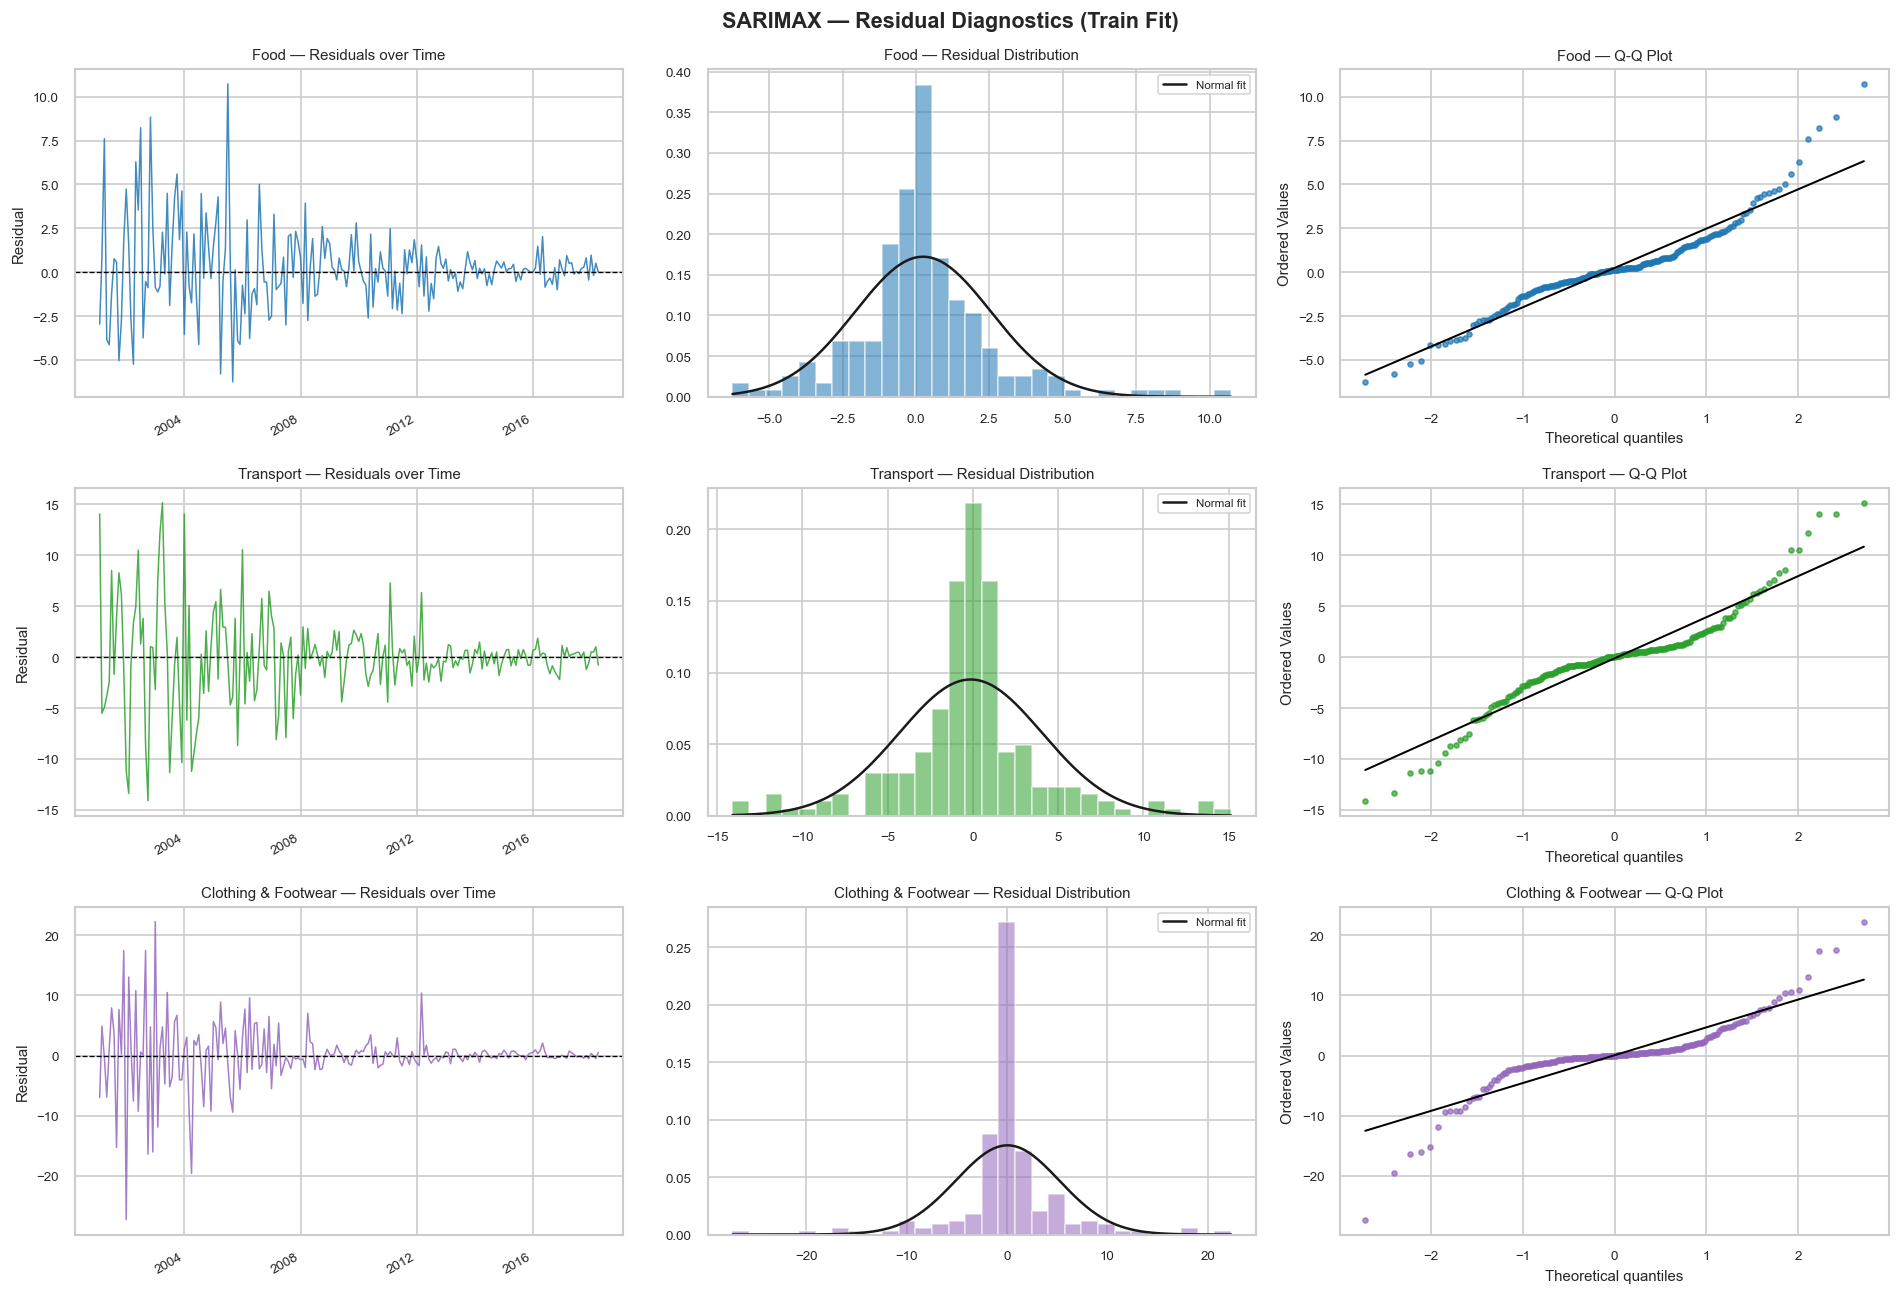


  Residual diagnostic plot saved : ../outputs/sarimax_residual_diagnostics.png

═════════════════════════════════════════════════════════════════
  ✔  SARIMAX complete.
  Models  → ../models/sarimax_{{target}}.pkl  (x3)
  Outputs → ../outputs/sarimax_pred_vs_actual_val.csv/.png
            ../outputs/sarimax_pred_vs_actual_test.csv/.png
            ../outputs/sarimax_residual_diagnostics.csv/.png
═════════════════════════════════════════════════════════════════


In [6]:
# ============================================================
# CELL 5 — SARIMAX BASE LEARNER
# ============================================================
# Key design decisions:
#   • Exog trimmed to a lean theoretically-motivated subset —
#     65 regressors on 207 obs would overfit severely
#   • Structural dummies excluded from SARIMAX exog: all three
#     are constant-zero in the train window (train ends Apr 2018,
#     COVID = Mar 2020, devaluation = Jun 2023, rebase = Jan 2024)
#   • AIC grid search over p ∈ {1,2}, q ∈ {1,2},
#     P ∈ {0,1}, Q ∈ {0,1}, d=1, D=1, s=12
#   • Val predictions produced for meta-learner (Cell 8)
#   • Outputs: model pkl, predicted-vs-actual CSV + plot,
#     Ljung-Box + Jarque-Bera residual diagnostics
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera, norm, probplot
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../models',  exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

# ── Lean exog feature set for SARIMAX ────────────────────────
SARIMAX_FEATURES = [
    'exchange_rate', 'oil_price',
    'domestic_production', 'crude_oil_export',
    'oil_fx_interaction',
    'all_items_mom_lag_1',
]

TARGET_NAMES  = ['food_mom', 'transport_mom', 'clothing_mom']
TARGET_LABELS = ['Food', 'Transport', 'Clothing & Footwear']
TARGET_COLORS = ['#1f77b4', '#2ca02c', '#9467bd']

sarimax_models     = {}
sarimax_val_preds  = {}
sarimax_test_preds = {}

print("═"*65)
print("  SARIMAX — AIC Grid Search & Fitting")
print("═"*65)

for target, label in zip(TARGET_NAMES, TARGET_LABELS):

    print(f"\n  ▸ {label}")

    own_lags  = [f'{target}_lag_1', f'{target}_lag_2']
    exog_cols = SARIMAX_FEATURES + own_lags

    X_tr = X_train[exog_cols].values
    X_va = X_val[exog_cols].values
    X_te = X_test[exog_cols].values
    y_tr = y_train[target].values

    best_aic    = np.inf
    best_res    = None
    best_order  = None
    best_sorder = None
    aic_log     = []

    for p in [1, 2]:
        for q in [1, 2]:
            for P in [0, 1]:
                for Q in [0, 1]:
                    try:
                        mdl = sm.tsa.SARIMAX(
                            y_tr,
                            exog=X_tr,
                            order=(p, 1, q),
                            seasonal_order=(P, 1, Q, 12),
                            enforce_stationarity=False,
                            enforce_invertibility=False,
                        )
                        res = mdl.fit(disp=False, maxiter=200)
                        aic_log.append({
                            'order'   : (p, 1, q),
                            'seasonal': (P, 1, Q, 12),
                            'aic'     : res.aic,
                        })
                        if res.aic < best_aic:
                            best_aic    = res.aic
                            best_res    = res
                            best_order  = (p, 1, q)
                            best_sorder = (P, 1, Q, 12)
                    except Exception:
                        continue

    sarimax_models[target] = best_res

    model_path = f'../models/sarimax_{target}.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(best_res, f)

    print(f"    Best ARIMA order    : {best_order}")
    print(f"    Best seasonal order : {best_sorder}")
    print(f"    Best AIC            : {best_aic:.2f}")
    print(f"    Model saved         : {model_path}")

    aic_df = (pd.DataFrame(aic_log)
                .sort_values('aic')
                .head(5)
                .reset_index(drop=True))
    print(f"\n    Top-5 AIC candidates:")
    for _, row in aic_df.iterrows():
        marker = ' ◄ best' if (row['order'] == best_order and
                               row['seasonal'] == best_sorder) else ''
        print(f"      ARIMA{row['order']} x SARIMA{row['seasonal']}  "
              f"AIC={row['aic']:.2f}{marker}")

    # ── Val predictions ───────────────────────────────────────
    # Append val exog and forecast step-by-step from end of train
    val_forecast = best_res.apply(
        endog=y_tr, exog=X_tr,
    ).forecast(steps=len(X_va), exog=X_va)
    sarimax_val_preds[target] = val_forecast

    # ── Test predictions (refit on train+val) ─────────────────
    y_tr_va = np.concatenate([y_tr, y_val[target].values])
    X_tr_va = np.vstack([X_tr, X_va])

    mdl_full = sm.tsa.SARIMAX(
        y_tr_va,
        exog=X_tr_va,
        order=best_order,
        seasonal_order=best_sorder,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    res_full = mdl_full.fit(disp=False, maxiter=200)
    sarimax_test_preds[target] = res_full.forecast(
        steps=len(X_te), exog=X_te
    )

    # ── Residual diagnostics (console) ───────────────────────
    residuals = best_res.resid
    lb10 = acorr_ljungbox(residuals, lags=[10], return_df=True)
    lb20 = acorr_ljungbox(residuals, lags=[20], return_df=True)
    jb_res = jarque_bera(residuals); jb_stat = float(jb_res.statistic); jb_pval = float(jb_res.pvalue); jb_skew = float(np.array(residuals).mean()); jb_kurt = float(pd.Series(residuals).kurt())

    print(f"\n    Residual Diagnostics (train fit):")
    print(f"    Ljung-Box lag=10 : stat={lb10['lb_stat'].iloc[0]:.3f}, "
          f"p={lb10['lb_pvalue'].iloc[0]:.4f}"
          + (" ✔" if lb10['lb_pvalue'].iloc[0] > 0.05 else " ⚠ autocorr."))
    print(f"    Ljung-Box lag=20 : stat={lb20['lb_stat'].iloc[0]:.3f}, "
          f"p={lb20['lb_pvalue'].iloc[0]:.4f}"
          + (" ✔" if lb20['lb_pvalue'].iloc[0] > 0.05 else " ⚠ autocorr."))
    print(f"    Jarque-Bera      : stat={jb_stat:.3f}, p={jb_pval:.4f}"
          + (" ✔" if jb_pval > 0.05 else " ⚠ non-normal"))
    print(f"      skew={jb_skew:.3f}, excess kurtosis={jb_kurt:.3f}")


# ════════════════════════════════════════════════════════════
# OUTPUT 1 — Predicted vs Actual MoM (Val & Test)
# ════════════════════════════════════════════════════════════
print("\n\n" + "═"*65)
print("  OUTPUT 1 — Predicted vs Actual MoM")
print("═"*65)

for split_name, split_df, y_split, preds_dict in [
    ('val',  val_df,  y_val,  sarimax_val_preds),
    ('test', test_df, y_test, sarimax_test_preds),
]:
    rows = []

    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)
    fig.suptitle(
        f'SARIMAX — Predicted vs Actual MoM%  '
        f'[{split_name.capitalize()} Set]',
        fontweight='bold', fontsize=13
    )

    for ax, target, label, color in zip(
        axes, TARGET_NAMES, TARGET_LABELS, TARGET_COLORS
    ):
        actual = y_split[target].values
        dates  = pd.to_datetime(split_df['date'].values)
        pred   = np.array(preds_dict[target])

        n = min(len(actual), len(pred), len(dates))
        actual, pred, dates = actual[:n], pred[:n], dates[:n]

        mae  = np.mean(np.abs(actual - pred))
        rmse = np.sqrt(np.mean((actual - pred) ** 2))
        corr = np.corrcoef(actual, pred)[0, 1] if n > 1 else np.nan

        ax.plot(dates, actual, color='black', linewidth=1.5,
                label='Actual',    marker='o', markersize=3.5)
        ax.plot(dates, pred,   color=color,  linewidth=1.5,
                label='Predicted', marker='s', markersize=3.5,
                linestyle='--')
        ax.fill_between(dates, actual, pred, alpha=0.12, color=color)
        ax.axhline(0, color='grey', linewidth=0.7, linestyle=':')
        ax.set_title(
            f'{label}   MAE={mae:.3f}   RMSE={rmse:.3f}   r={corr:.3f}',
            fontsize=10
        )
        ax.set_ylabel('MoM %')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
        ax.legend(loc='upper left', fontsize=8)

        for d, a, p_ in zip(dates, actual, pred):
            rows.append({
                'date'     : d.strftime('%Y-%m-%d'),
                'target'   : label,
                'actual'   : round(float(a),  4),
                'predicted': round(float(p_), 4),
                'error'    : round(float(a - p_), 4),
            })

    plt.tight_layout()
    plot_path = f'../outputs/sarimax_pred_vs_actual_{split_name}.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Plot saved : {plot_path}")

    csv_path = f'../outputs/sarimax_pred_vs_actual_{split_name}.csv'
    pd.DataFrame(rows).to_csv(csv_path, index=False)
    print(f"  CSV  saved : {csv_path}")


# ════════════════════════════════════════════════════════════
# OUTPUT 2 — Residual Diagnostics (CSV + Plot)
# ════════════════════════════════════════════════════════════
print("\n" + "═"*65)
print("  OUTPUT 2 — Residual Diagnostics")
print("═"*65)

diag_rows = []
for target, label in zip(TARGET_NAMES, TARGET_LABELS):
    res       = sarimax_models[target]
    residuals = res.resid
    lb10 = acorr_ljungbox(residuals, lags=[10], return_df=True)
    lb20 = acorr_ljungbox(residuals, lags=[20], return_df=True)
    jb_res = jarque_bera(residuals); jb_stat = float(jb_res.statistic); jb_pval = float(jb_res.pvalue); jb_skew = float(np.array(residuals).mean()); jb_kurt = float(pd.Series(residuals).kurt())
    diag_rows.append({
        'target'              : label,
        'best_order'          : str(res.model.order),
        'best_seasonal_order' : str(res.model.seasonal_order),
        'aic'                 : round(res.aic,  3),
        'lb_stat_lag10'       : round(lb10['lb_stat'].iloc[0],   3),
        'lb_pval_lag10'       : round(lb10['lb_pvalue'].iloc[0], 4),
        'lb_stat_lag20'       : round(lb20['lb_stat'].iloc[0],   3),
        'lb_pval_lag20'       : round(lb20['lb_pvalue'].iloc[0], 4),
        'jb_stat'             : round(jb_stat, 3),
        'jb_pval'             : round(jb_pval, 4),
        'jb_skewness'         : round(jb_skew, 3),
        'jb_excess_kurtosis'  : round(jb_kurt, 3),
        'lb_lag10_pass'       : lb10['lb_pvalue'].iloc[0] > 0.05,
        'jb_pass'             : jb_pval > 0.05,
    })

diag_df   = pd.DataFrame(diag_rows)
diag_path = '../outputs/sarimax_residual_diagnostics.csv'
diag_df.to_csv(diag_path, index=False)
print(f"  Diagnostics CSV saved : {diag_path}")
print()
print(diag_df[['target','best_order','aic',
               'lb_pval_lag10','jb_pval',
               'lb_lag10_pass','jb_pass']].to_string(index=False))

# Residual diagnostic plots: residuals over time, histogram, Q-Q
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
fig.suptitle('SARIMAX — Residual Diagnostics (Train Fit)',
             fontweight='bold', fontsize=13)

for row_i, (target, label, color) in enumerate(
    zip(TARGET_NAMES, TARGET_LABELS, TARGET_COLORS)
):
    residuals = sarimax_models[target].resid
    dates_tr  = pd.to_datetime(train_df['date'].values)[:len(residuals)]

    # Residuals over time
    ax = axes[row_i][0]
    ax.plot(dates_tr, residuals, color=color, linewidth=0.9, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{label} — Residuals over Time', fontsize=9)
    ax.set_ylabel('Residual')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    # Histogram + normal overlay
    ax = axes[row_i][1]
    ax.hist(residuals, bins=30, color=color, alpha=0.55,
            edgecolor='white', density=True)
    mu, sigma = residuals.mean(), residuals.std()
    x = np.linspace(residuals.min(), residuals.max(), 200)
    ax.plot(x, norm.pdf(x, mu, sigma), 'k-', linewidth=1.5,
            label='Normal fit')
    ax.set_title(f'{label} — Residual Distribution', fontsize=9)
    ax.legend(fontsize=7)

    # Q-Q plot
    ax = axes[row_i][2]
    probplot(residuals, dist='norm', plot=ax)
    ax.set_title(f'{label} — Q-Q Plot', fontsize=9)
    ax.get_lines()[0].set(markersize=3, color=color, alpha=0.7)
    ax.get_lines()[1].set(color='black', linewidth=1.2)

plt.tight_layout()
diag_plot_path = '../outputs/sarimax_residual_diagnostics.png'
plt.savefig(diag_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  Residual diagnostic plot saved : {diag_plot_path}")

print("\n" + "═"*65)
print("  ✔  SARIMAX complete.")
print("  Models  → ../models/sarimax_{{target}}.pkl  (x3)")
print("  Outputs → ../outputs/sarimax_pred_vs_actual_val.csv/.png")
print("            ../outputs/sarimax_pred_vs_actual_test.csv/.png")
print("            ../outputs/sarimax_residual_diagnostics.csv/.png")
print("═"*65)

═════════════════════════════════════════════════════════════════
  RANDOM FOREST — Grid Search & Fitting
═════════════════════════════════════════════════════════════════

  ▸ Food
    Best params:
      max_depth           : 15
      max_features        : sqrt
      min_samples_leaf    : 1
      min_samples_split   : 2
      n_estimators        : 100
    Best CV MAE         : 1.0502
    OOB score (R²)      : -0.0071
    Model saved         : ../models/rf_food_mom.pkl

    Top-10 features:
       1. food_mom_lag_1                           0.0568
       2. food_mom_lag_2                           0.0459
       3. food_mom_roll_mean_3                     0.0371
       4. all_items_mom_lag_1                      0.0366
       5. transport_mom_roll_mean_3                0.0356
       6. food_mom_lag_3                           0.0347
       7. transport_mom_lag_3                      0.0343
       8. all_items_mom_roll_mean_3                0.0314
       9. exchange_rate_roll_mean_6     

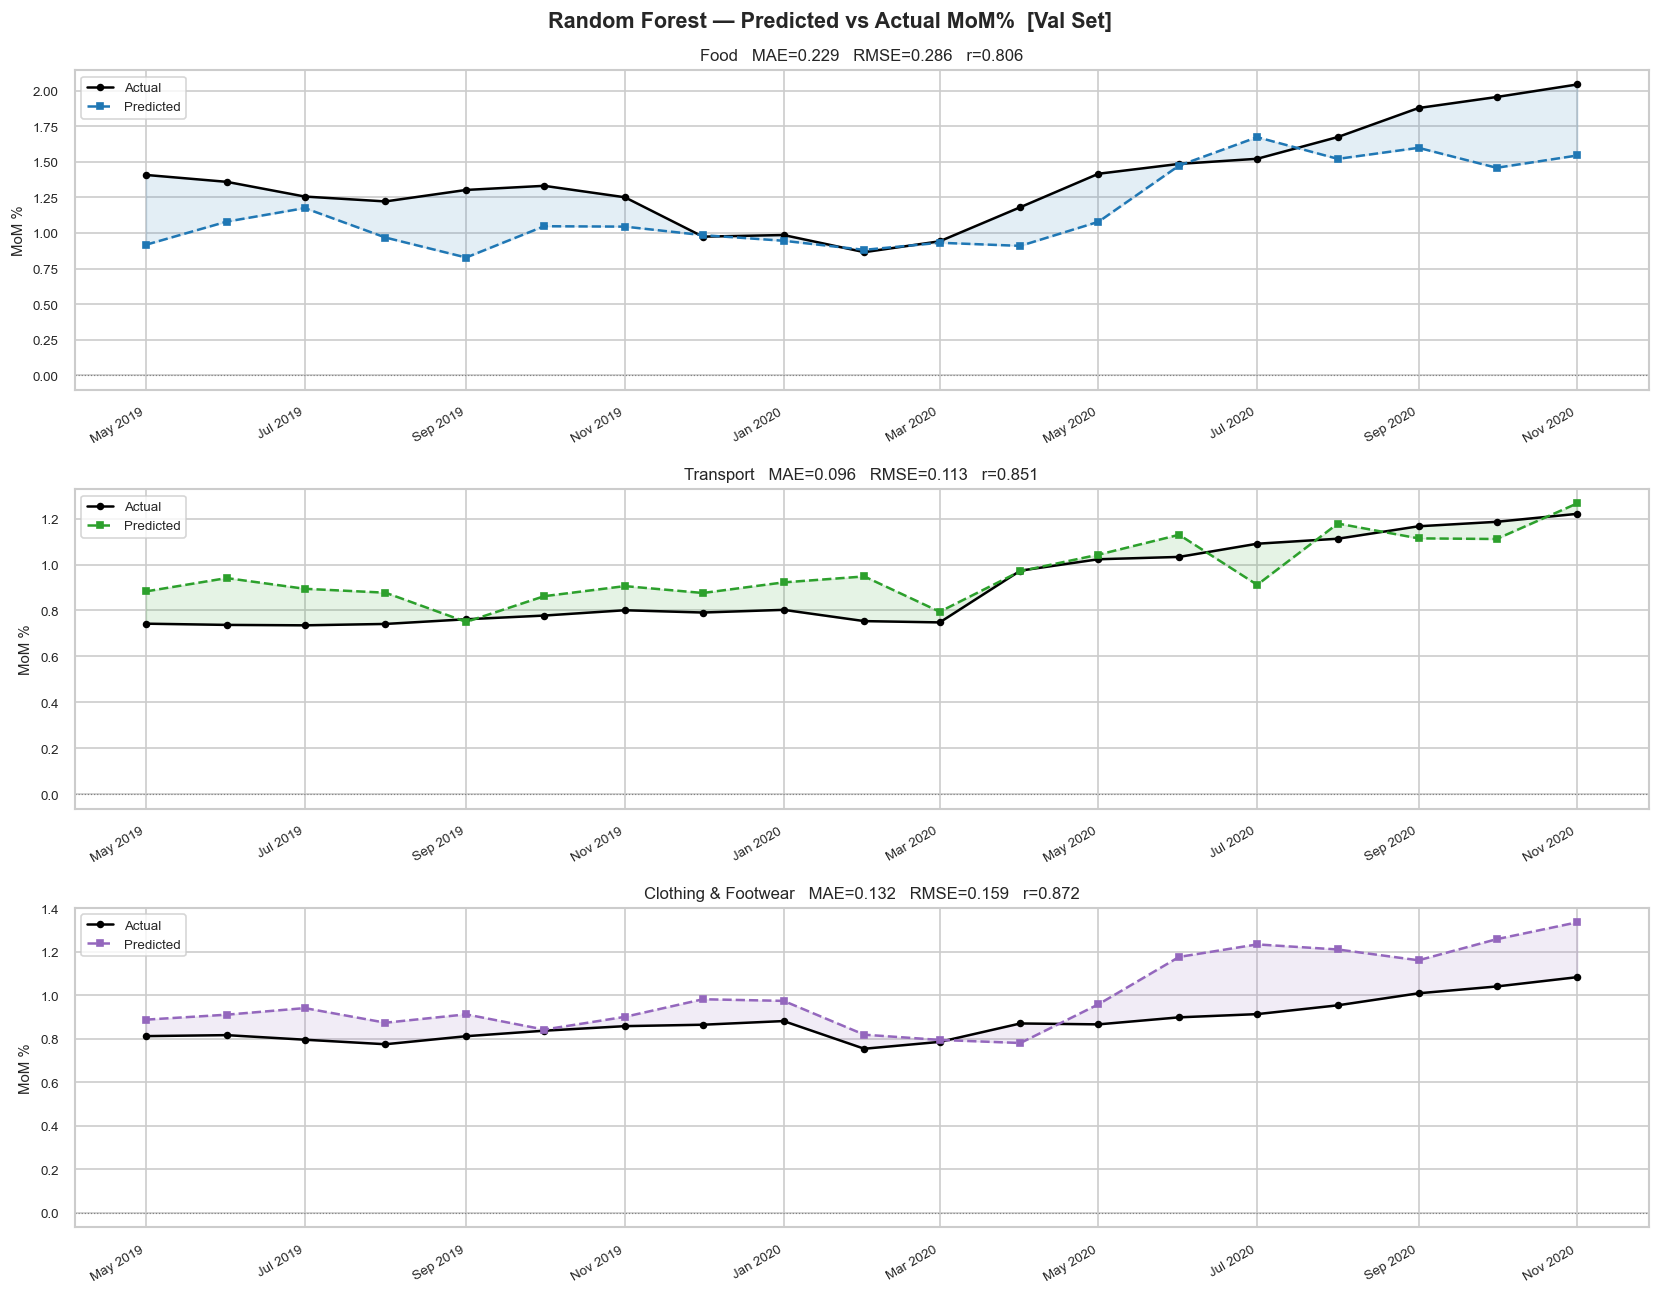

  Plot saved : ../outputs/rf_pred_vs_actual_val.png
  CSV  saved : ../outputs/rf_pred_vs_actual_val.csv


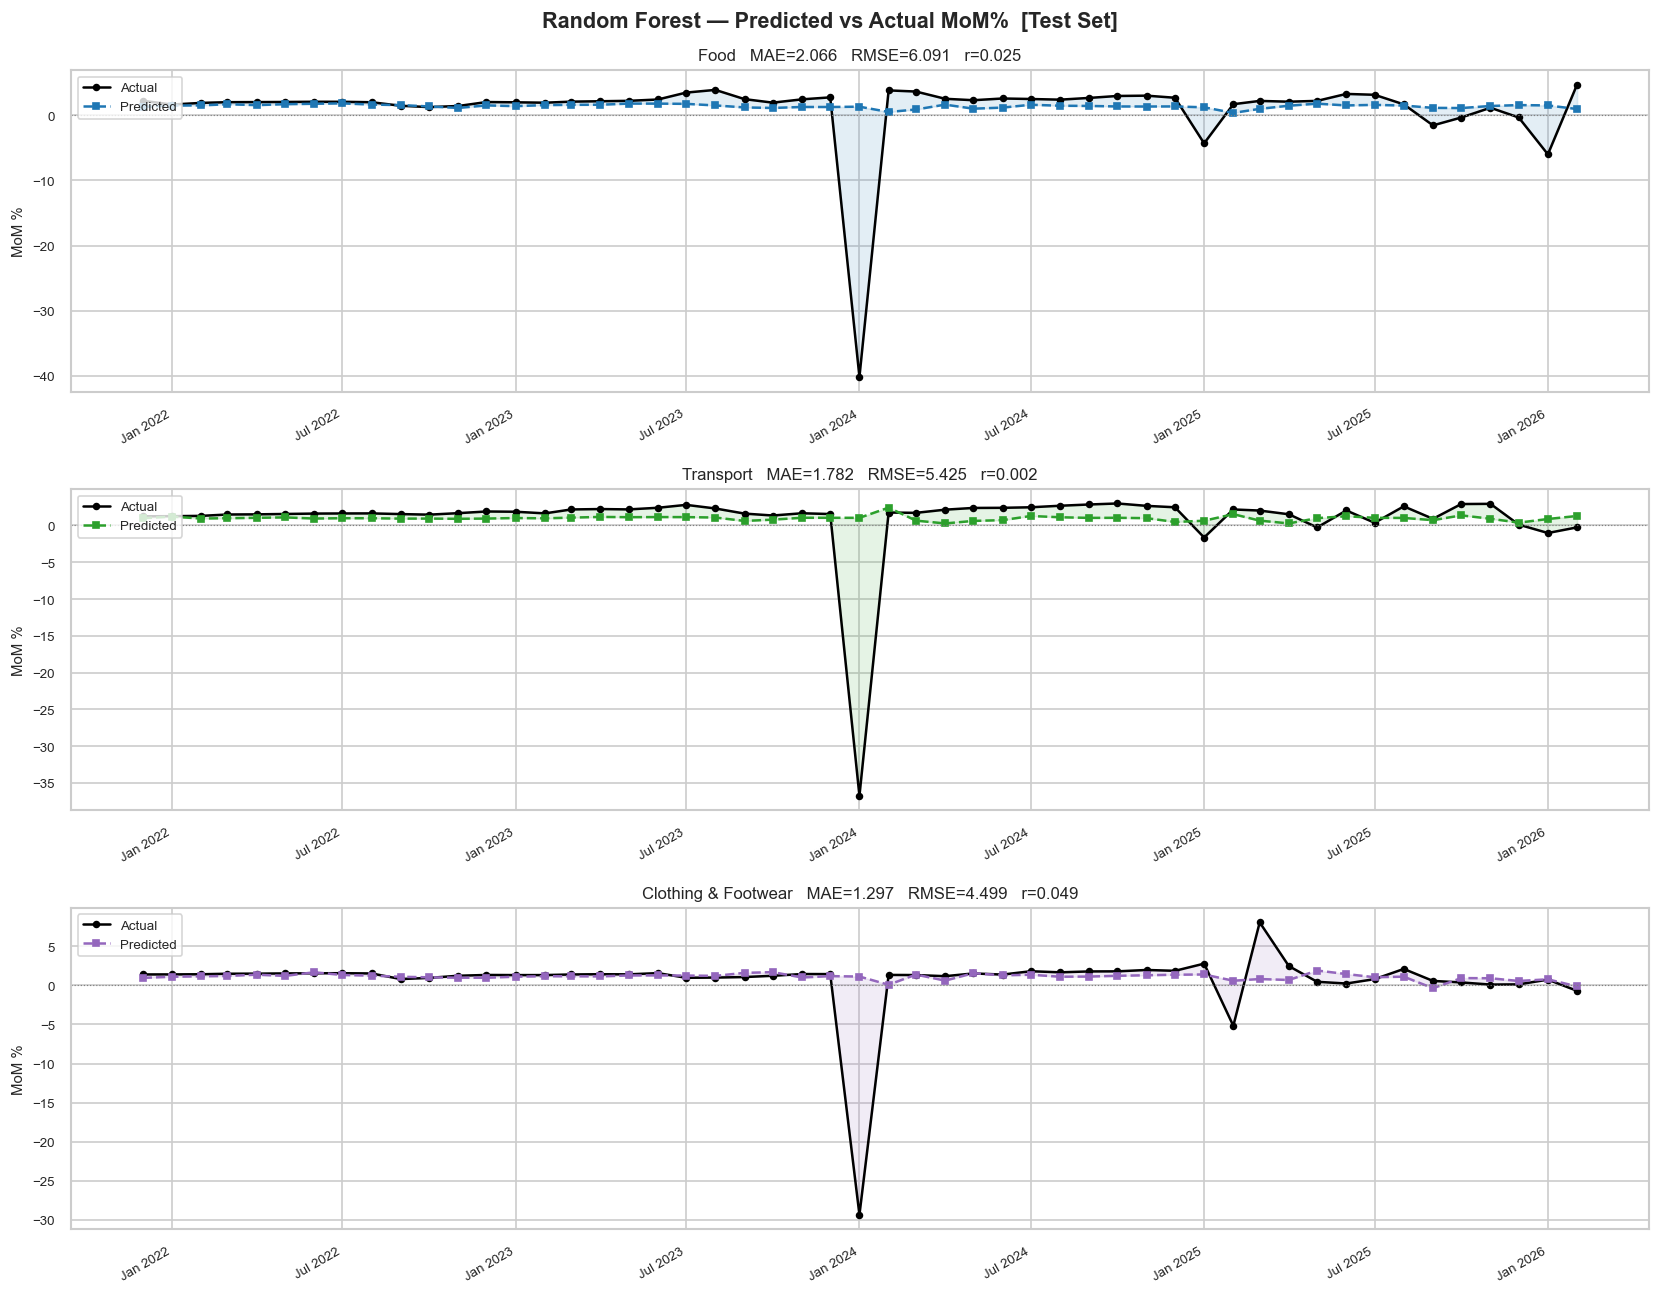

  Plot saved : ../outputs/rf_pred_vs_actual_test.png
  CSV  saved : ../outputs/rf_pred_vs_actual_test.csv

═════════════════════════════════════════════════════════════════
  OUTPUT 2 — Feature Importance
═════════════════════════════════════════════════════════════════
  Feature importance CSV saved : ../outputs/rf_feature_importance.csv


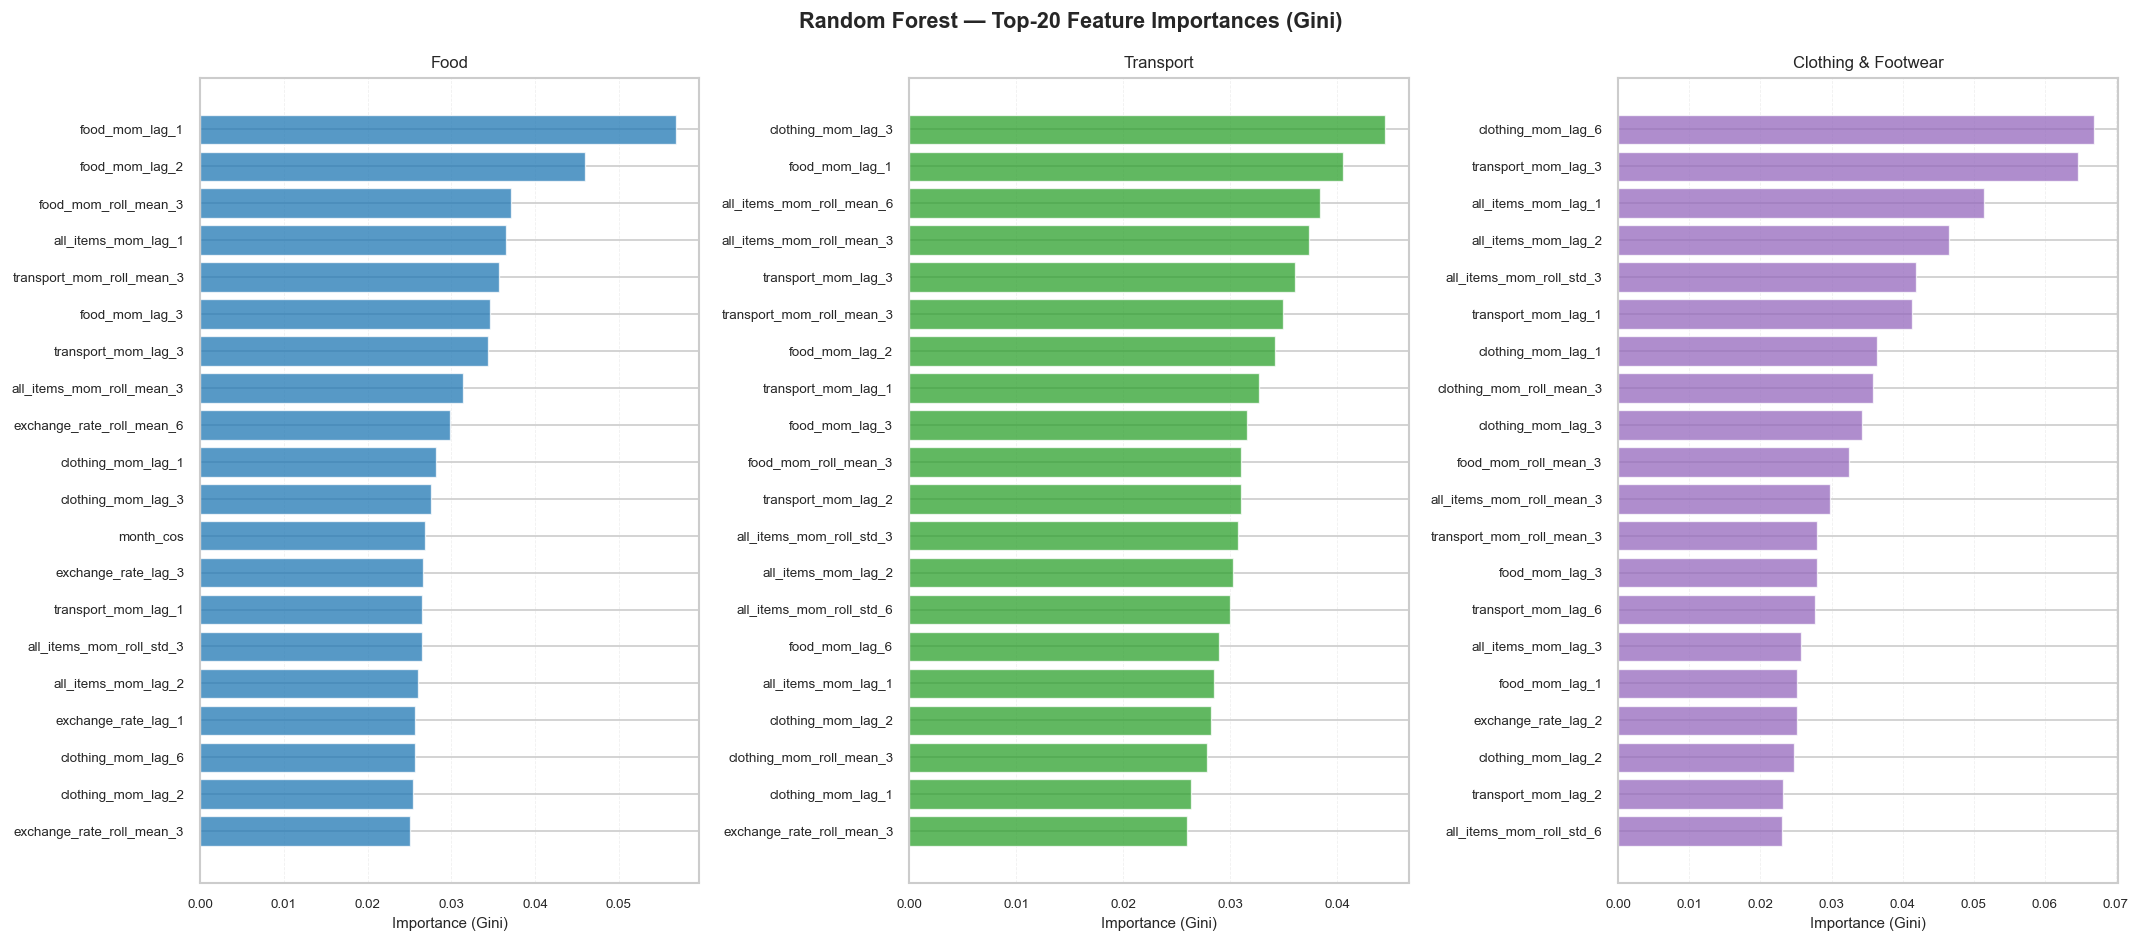

  Feature importance plot saved : ../outputs/rf_feature_importance.png

  Feature group importance summary:
  (mean importance across all features in each group)


  Food:
    Macro raw              : 0.0068
    Macro lags             : 0.0089
    Macro rolling          : 0.0077
    Headline MoM lags      : 0.0266
    Target MoM lags        : 0.0309
    Target MoM rolling     : 0.0315
    Derived macro          : 0.0086
    Cyclical encoding      : 0.0195
    Structural dummies     : 0.0000

  Transport:
    Macro raw              : 0.0070
    Macro lags             : 0.0078
    Macro rolling          : 0.0073
    Headline MoM lags      : 0.0313
    Target MoM lags        : 0.0314
    Target MoM rolling     : 0.0313
    Derived macro          : 0.0093
    Cyclical encoding      : 0.0085
    Structural dummies     : 0.0000

  Clothing & Footwear:
    Macro raw              : 0.0079
    Macro lags             : 0.0068
    Macro rolling          : 0.0051
    Headline MoM lags      : 0.033

In [8]:
# ============================================================
# CELL 6 — RANDOM FOREST BASE LEARNER
# ============================================================
# Key design decisions:
#   • Uses ALL 65 engineered features (unlike SARIMAX which 
#     needed lean exog to avoid overfitting)
#   • Grid search over n_estimators, max_depth, min_samples_split
#   • Out-of-bag score used for validation during grid search
#   • Feature importance ranking with Gini importance
#   • Val predictions produced for meta-learner (Cell 8)
#   • Outputs: model pkl, predicted-vs-actual CSV + plot,
#     feature importance CSV + plot
# ============================================================

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../models',  exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

TARGET_NAMES  = ['food_mom', 'transport_mom', 'clothing_mom']
TARGET_LABELS = ['Food', 'Transport', 'Clothing & Footwear']
TARGET_COLORS = ['#1f77b4', '#2ca02c', '#9467bd']

rf_models       = {}
rf_val_preds    = {}
rf_test_preds   = {}
rf_feature_imp  = {}

print("═"*65)
print("  RANDOM FOREST — Grid Search & Fitting")
print("═"*65)

# ── Hyperparameter grid ───────────────────────────────────────
param_grid = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [10, 15, 20, None],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2],
    'max_features'      : ['sqrt', 'log2'],
}

# TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=3)

for target, label in zip(TARGET_NAMES, TARGET_LABELS):

    print(f"\n  ▸ {label}")

    y_tr = y_train[target].values
    y_va = y_val[target].values
    y_te = y_test[target].values

    # ── Grid search with TimeSeriesSplit ─────────────────────
    base_rf = RandomForestRegressor(
        random_state=42, 
        oob_score=True,
        n_jobs=-1
    )

    grid_search = GridSearchCV(
        estimator=base_rf,
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train, y_tr)
    best_rf = grid_search.best_estimator_

    print(f"    Best params:")
    for k, v in grid_search.best_params_.items():
        print(f"      {k:<20}: {v}")
    print(f"    Best CV MAE         : {-grid_search.best_score_:.4f}")
    print(f"    OOB score (R²)      : {best_rf.oob_score_:.4f}")

    # ── Save model ────────────────────────────────────────────
    rf_models[target] = best_rf
    model_path = f'../models/rf_{target}.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(best_rf, f)
    print(f"    Model saved         : {model_path}")

    # ── Feature importance ────────────────────────────────────
    importances = best_rf.feature_importances_
    feature_df  = pd.DataFrame({
        'feature'   : X_train.columns,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    rf_feature_imp[target] = feature_df

    print(f"\n    Top-10 features:")
    for idx, row in feature_df.head(10).iterrows():
        print(f"      {idx+1:>2}. {row['feature']:<40} {row['importance']:.4f}")

    # ── Val predictions ───────────────────────────────────────
    val_preds = best_rf.predict(X_val)
    rf_val_preds[target] = val_preds

    # ── Test predictions ──────────────────────────────────────
    # Refit on train+val for test prediction
    X_tr_va = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
    y_tr_va = np.concatenate([y_tr, y_va])

    rf_full = RandomForestRegressor(**grid_search.best_params_, random_state=42, n_jobs=-1)
    rf_full.fit(X_tr_va, y_tr_va)
    test_preds = rf_full.predict(X_test)
    rf_test_preds[target] = test_preds


# ════════════════════════════════════════════════════════════
# OUTPUT 1 — Predicted vs Actual MoM (Val & Test)
# ════════════════════════════════════════════════════════════
print("\n\n" + "═"*65)
print("  OUTPUT 1 — Predicted vs Actual MoM")
print("═"*65)

for split_name, split_df, y_split, preds_dict in [
    ('val',  val_df,  y_val,  rf_val_preds),
    ('test', test_df, y_test, rf_test_preds),
]:
    rows = []

    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)
    fig.suptitle(
        f'Random Forest — Predicted vs Actual MoM%  '
        f'[{split_name.capitalize()} Set]',
        fontweight='bold', fontsize=13
    )

    for ax, target, label, color in zip(
        axes, TARGET_NAMES, TARGET_LABELS, TARGET_COLORS
    ):
        actual = y_split[target].values
        dates  = pd.to_datetime(split_df['date'].values)
        pred   = preds_dict[target]

        n = min(len(actual), len(pred), len(dates))
        actual, pred, dates = actual[:n], pred[:n], dates[:n]

        mae  = np.mean(np.abs(actual - pred))
        rmse = np.sqrt(np.mean((actual - pred) ** 2))
        corr = np.corrcoef(actual, pred)[0, 1] if n > 1 else np.nan

        ax.plot(dates, actual, color='black', linewidth=1.5,
                label='Actual',    marker='o', markersize=3.5)
        ax.plot(dates, pred,   color=color,  linewidth=1.5,
                label='Predicted', marker='s', markersize=3.5,
                linestyle='--')
        ax.fill_between(dates, actual, pred, alpha=0.12, color=color)
        ax.axhline(0, color='grey', linewidth=0.7, linestyle=':')
        ax.set_title(
            f'{label}   MAE={mae:.3f}   RMSE={rmse:.3f}   r={corr:.3f}',
            fontsize=10
        )
        ax.set_ylabel('MoM %')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
        ax.legend(loc='upper left', fontsize=8)

        for d, a, p_ in zip(dates, actual, pred):
            rows.append({
                'date'     : d.strftime('%Y-%m-%d'),
                'target'   : label,
                'actual'   : round(float(a),  4),
                'predicted': round(float(p_), 4),
                'error'    : round(float(a - p_), 4),
            })

    plt.tight_layout()
    plot_path = f'../outputs/rf_pred_vs_actual_{split_name}.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Plot saved : {plot_path}")

    csv_path = f'../outputs/rf_pred_vs_actual_{split_name}.csv'
    pd.DataFrame(rows).to_csv(csv_path, index=False)
    print(f"  CSV  saved : {csv_path}")


# ════════════════════════════════════════════════════════════
# OUTPUT 2 — Feature Importance (CSV + Plot)
# ════════════════════════════════════════════════════════════
print("\n" + "═"*65)
print("  OUTPUT 2 — Feature Importance")
print("═"*65)

# Combine all three target importance rankings into one CSV
all_imp_rows = []
for target, label in zip(TARGET_NAMES, TARGET_LABELS):
    df_imp = rf_feature_imp[target].copy()
    df_imp['target'] = label
    all_imp_rows.append(df_imp)

all_imp_df = pd.concat(all_imp_rows, axis=0).reset_index(drop=True)
imp_csv_path = '../outputs/rf_feature_importance.csv'
all_imp_df.to_csv(imp_csv_path, index=False)
print(f"  Feature importance CSV saved : {imp_csv_path}")

# Plot: Top-20 features for each target
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
fig.suptitle('Random Forest — Top-20 Feature Importances (Gini)',
             fontweight='bold', fontsize=13)

for ax, target, label, color in zip(axes, TARGET_NAMES, TARGET_LABELS, TARGET_COLORS):
    top_features = rf_feature_imp[target].head(20)
    
    ax.barh(
        range(len(top_features)),
        top_features['importance'],
        color=color,
        alpha=0.75,
        edgecolor='white',
        linewidth=0.8
    )
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Importance (Gini)', fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
imp_plot_path = '../outputs/rf_feature_importance.png'
plt.savefig(imp_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Feature importance plot saved : {imp_plot_path}")

# Print summary of feature group importance
print(f"\n  Feature group importance summary:")
print(f"  (mean importance across all features in each group)\n")

feature_groups = {
    'Macro raw'          : [c for c in X_train.columns if c in ['exchange_rate', 'oil_price', 'domestic_production', 'crude_oil_export']],
    'Macro lags'         : [c for c in X_train.columns if '_lag_' in c and any(m in c for m in ['exchange_rate', 'oil_price', 'domestic_production', 'crude_oil_export'])],
    'Macro rolling'      : [c for c in X_train.columns if 'roll_' in c and any(m in c for m in ['exchange_rate', 'oil_price', 'domestic_production', 'crude_oil_export'])],
    'Headline MoM lags'  : [c for c in X_train.columns if 'all_items_mom' in c],
    'Target MoM lags'    : [c for c in X_train.columns if any(t in c for t in TARGET_NAMES) and '_lag_' in c],
    'Target MoM rolling' : [c for c in X_train.columns if any(t in c for t in TARGET_NAMES) and 'roll_' in c],
    'Derived macro'      : [c for c in X_train.columns if c in ['oil_fx_interaction', 'oil_fx_interaction_lag_1', 'crude_export_prod_ratio', 'crude_export_prod_ratio_lag_1', 'exchange_rate_yoy', 'oil_price_yoy']],
    'Cyclical encoding'  : [c for c in X_train.columns if 'month_' in c],
    'Structural dummies' : [c for c in X_train.columns if 'post_' in c],
}

for target, label in zip(TARGET_NAMES, TARGET_LABELS):
    print(f"\n  {label}:")
    imp_dict = dict(zip(rf_feature_imp[target]['feature'], 
                       rf_feature_imp[target]['importance']))
    
    for group_name, group_cols in feature_groups.items():
        group_imps = [imp_dict.get(c, 0) for c in group_cols]
        mean_imp = np.mean(group_imps) if group_imps else 0
        print(f"    {group_name:<22} : {mean_imp:.4f}")


print("\n" + "═"*65)
print("  ✔  Random Forest complete.")
print("  Models  → ../models/rf_{{target}}.pkl  (x3)")
print("  Outputs → ../outputs/rf_pred_vs_actual_val.csv/.png")
print("            ../outputs/rf_pred_vs_actual_test.csv/.png")
print("            ../outputs/rf_feature_importance.csv/.png")
print("═"*65)

═════════════════════════════════════════════════════════════════
  LSTM — Scaling, Architecture, & Training
═════════════════════════════════════════════════════════════════

  ▸ Food
    Architecture:
      Layer 1: LSTM(64) + Dropout(0.2)
      Layer 2: LSTM(32) + Dropout(0.2)
      Layer 3: Dense(16, relu)
      Output : Dense(1)
    Total params: 46,241


    Training:
      Epochs run       : 24
      Early stop epoch : 23
      Best epoch       : 3
      Train MAE        : 1.3521
      Val MAE          : 0.2602
    Model saved         : ../models/lstm_food_mom.h5
    Scaler saved        : ../models/lstm_food_mom_scaler.pkl

  ▸ Transport
    Architecture:
      Layer 1: LSTM(64) + Dropout(0.2)
      Layer 2: LSTM(32) + Dropout(0.2)
      Layer 3: Dense(16, relu)
      Output : Dense(1)
    Total params: 46,241


    Training:
      Epochs run       : 25
      Early stop epoch : 24
      Best epoch       : 4
      Train MAE        : 1.9735
      Val MAE          : 0.0711
    Model saved         : ../models/lstm_transport_mom.h5
    Scaler saved        : ../models/lstm_transport_mom_scaler.pkl

  ▸ Clothing & Footwear
    Architecture:
      Layer 1: LSTM(64) + Dropout(0.2)
      Layer 2: LSTM(32) + Dropout(0.2)
      Layer 3: Dense(16, relu)
      Output : Dense(1)
    Total params: 46,241


    Training:
      Epochs run       : 27
      Early stop epoch : 26
      Best epoch       : 6
      Train MAE        : 1.6308
      Val MAE          : 0.1561
    Model saved         : ../models/lstm_clothing_mom.h5
    Scaler saved        : ../models/lstm_clothing_mom_scaler.pkl


═════════════════════════════════════════════════════════════════
  OUTPUT 1 — Training History (Loss Curves)
═════════════════════════════════════════════════════════════════


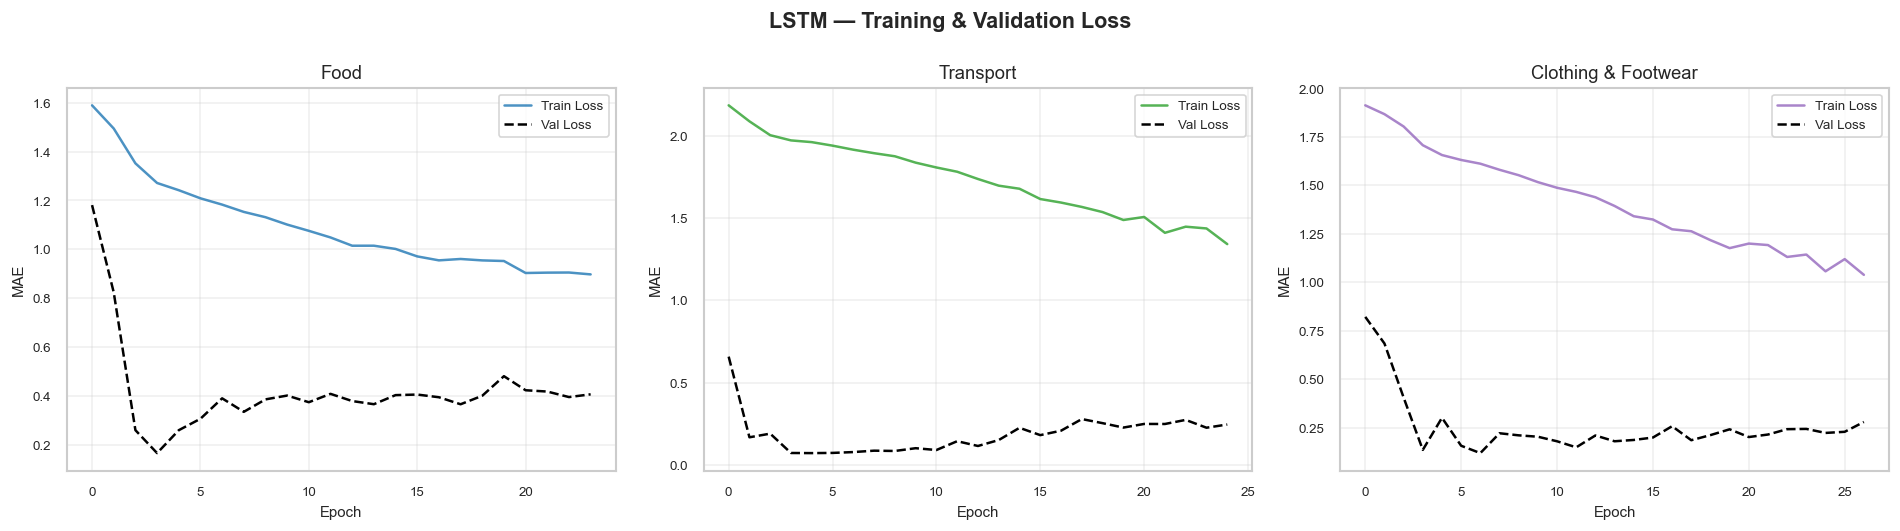

  Training history plot saved : ../outputs/lstm_training_history.png

═════════════════════════════════════════════════════════════════
  OUTPUT 2 — Predicted vs Actual MoM
═════════════════════════════════════════════════════════════════


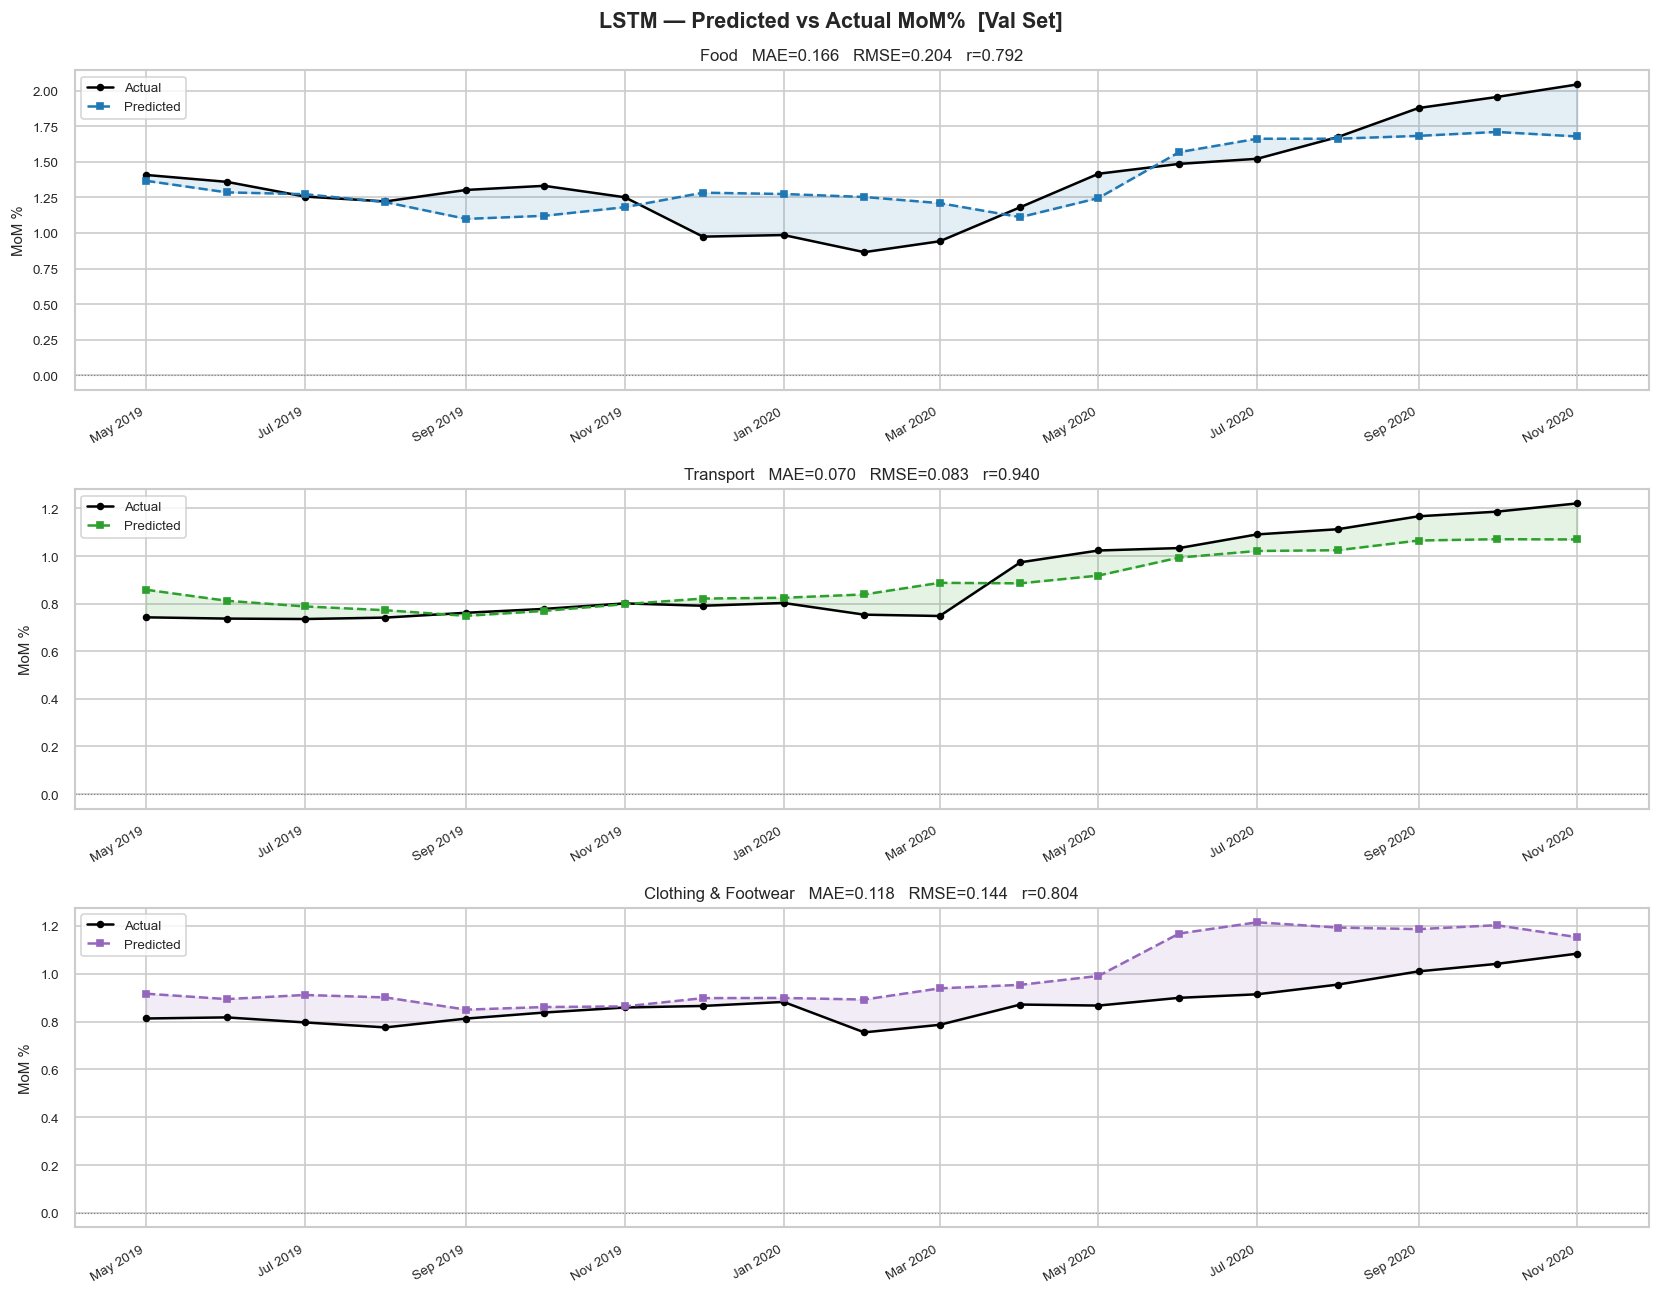

  Plot saved : ../outputs/lstm_pred_vs_actual_val.png
  CSV  saved : ../outputs/lstm_pred_vs_actual_val.csv


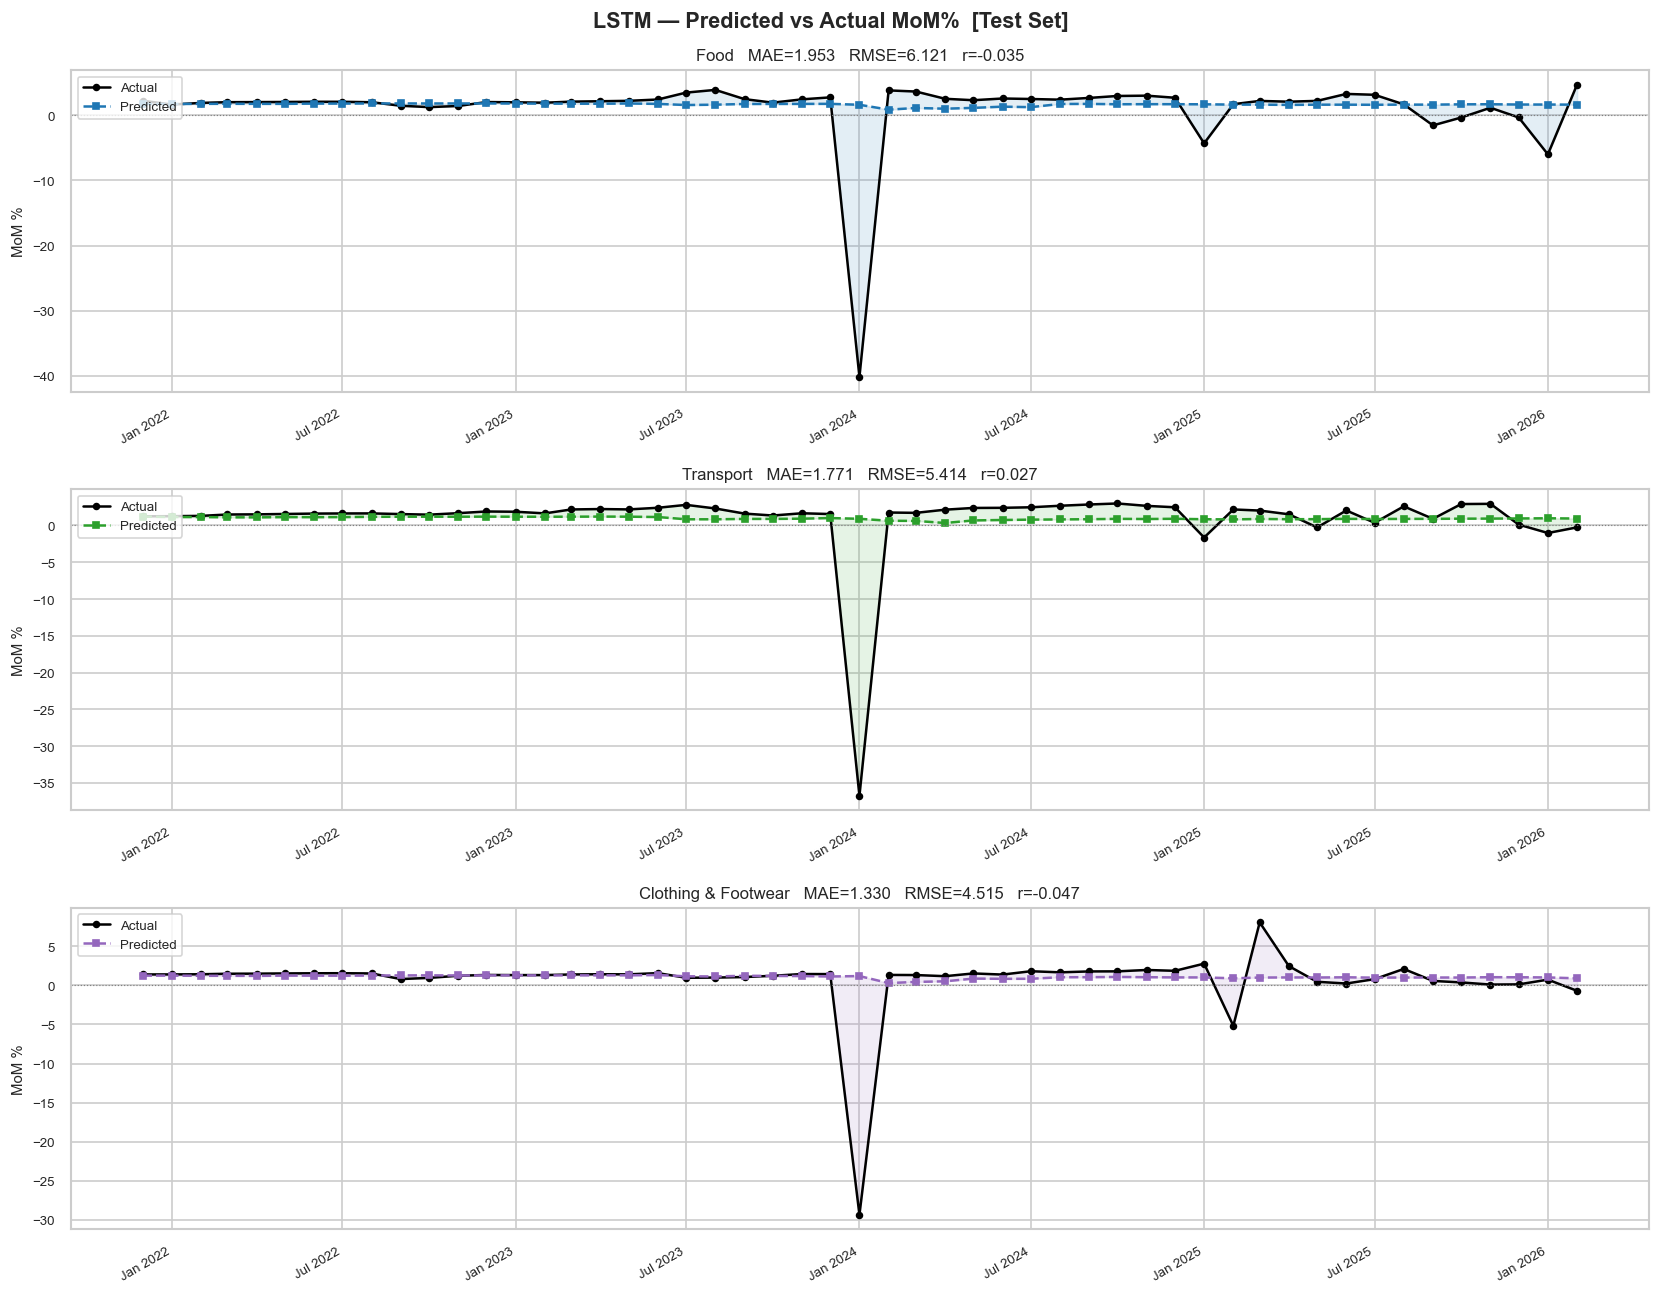

  Plot saved : ../outputs/lstm_pred_vs_actual_test.png
  CSV  saved : ../outputs/lstm_pred_vs_actual_test.csv

═════════════════════════════════════════════════════════════════
  ✔  LSTM complete.
  Models  → ../models/lstm_{{target}}.h5  (x3)
  Scalers → ../models/lstm_{{target}}_scaler.pkl  (x3)
  Outputs → ../outputs/lstm_training_history.png
            ../outputs/lstm_pred_vs_actual_val.csv/.png
            ../outputs/lstm_pred_vs_actual_test.csv/.png
═════════════════════════════════════════════════════════════════


In [9]:
# ============================================================
# CELL 7 — LSTM BASE LEARNER
# ============================================================
# Key design decisions:
#   • Reshapes X into 3D (samples, timesteps=1, features=65) for LSTM
#   • Uses ALL 65 engineered features
#   • Two-layer LSTM with dropout regularization
#   • Early stopping on validation loss (patience=20)
#   • StandardScaler normalization (fit on train only)
#   • Val predictions produced for meta-learner (Cell 8)
#   • Outputs: model h5, scaler pkl, predicted-vs-actual CSV + plot,
#     training history plot (loss curves)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# TensorFlow logging suppression
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

os.makedirs('../models',  exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

TARGET_NAMES  = ['food_mom', 'transport_mom', 'clothing_mom']
TARGET_LABELS = ['Food', 'Transport', 'Clothing & Footwear']
TARGET_COLORS = ['#1f77b4', '#2ca02c', '#9467bd']

lstm_models      = {}
lstm_scalers     = {}
lstm_histories   = {}
lstm_val_preds   = {}
lstm_test_preds  = {}

print("═"*65)
print("  LSTM — Scaling, Architecture, & Training")
print("═"*65)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

for target, label in zip(TARGET_NAMES, TARGET_LABELS):

    print(f"\n  ▸ {label}")

    # ── Normalize features ────────────────────────────────────
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_train)
    X_va_scaled = scaler.transform(X_val)
    X_te_scaled = scaler.transform(X_test)

    lstm_scalers[target] = scaler

    # ── Reshape to 3D for LSTM: (samples, timesteps, features) 
    # timesteps=1 because each row is already a snapshot with lags
    X_tr_lstm = X_tr_scaled.reshape((X_tr_scaled.shape[0], 1, X_tr_scaled.shape[1]))
    X_va_lstm = X_va_scaled.reshape((X_va_scaled.shape[0], 1, X_va_scaled.shape[1]))
    X_te_lstm = X_te_scaled.reshape((X_te_scaled.shape[0], 1, X_te_scaled.shape[1]))

    y_tr = y_train[target].values
    y_va = y_val[target].values
    y_te = y_test[target].values

    # ── Build LSTM architecture ───────────────────────────────
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(1, X_tr_scaled.shape[1])),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mean_absolute_error',
        metrics=['mean_squared_error']
    )

    print(f"    Architecture:")
    print(f"      Layer 1: LSTM(64) + Dropout(0.2)")
    print(f"      Layer 2: LSTM(32) + Dropout(0.2)")
    print(f"      Layer 3: Dense(16, relu)")
    print(f"      Output : Dense(1)")
    print(f"    Total params: {model.count_params():,}")

    # ── Callbacks ─────────────────────────────────────────────
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=0
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=0
    )

    # ── Train ─────────────────────────────────────────────────
    history = model.fit(
        X_tr_lstm, y_tr,
        validation_data=(X_va_lstm, y_va),
        epochs=200,
        batch_size=16,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    lstm_models[target]   = model
    lstm_histories[target] = history

    stopped_epoch = early_stop.stopped_epoch if early_stop.stopped_epoch > 0 else 200
    best_epoch    = stopped_epoch - early_stop.patience
    train_loss    = history.history['loss'][best_epoch - 1]
    val_loss      = history.history['val_loss'][best_epoch - 1]

    print(f"    Training:")
    print(f"      Epochs run       : {len(history.history['loss'])}")
    print(f"      Early stop epoch : {stopped_epoch}")
    print(f"      Best epoch       : {best_epoch}")
    print(f"      Train MAE        : {train_loss:.4f}")
    print(f"      Val MAE          : {val_loss:.4f}")

    # ── Save model & scaler ───────────────────────────────────
    model_path  = f'../models/lstm_{target}.h5'
    scaler_path = f'../models/lstm_{target}_scaler.pkl'

    model.save(model_path)
    with open(scaler_path, 'wb') as f:
        pickle.dump(scaler, f)

    print(f"    Model saved         : {model_path}")
    print(f"    Scaler saved        : {scaler_path}")

    # ── Val predictions ───────────────────────────────────────
    val_preds = model.predict(X_va_lstm, verbose=0).flatten()
    lstm_val_preds[target] = val_preds

    # ── Test predictions (refit on train+val) ─────────────────
    X_tr_va = np.vstack([X_train, X_val])
    y_tr_va = np.concatenate([y_tr, y_va])

    scaler_full = StandardScaler()
    X_tr_va_scaled = scaler_full.fit_transform(X_tr_va)
    X_te_scaled_full = scaler_full.transform(X_test)

    X_tr_va_lstm = X_tr_va_scaled.reshape((X_tr_va_scaled.shape[0], 1, X_tr_va_scaled.shape[1]))
    X_te_lstm_full = X_te_scaled_full.reshape((X_te_scaled_full.shape[0], 1, X_te_scaled_full.shape[1]))

    # Build and train final model
    model_full = Sequential([
        LSTM(64, return_sequences=True, input_shape=(1, X_tr_va_scaled.shape[1])),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model_full.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mean_absolute_error'
    )
    model_full.fit(X_tr_va_lstm, y_tr_va, epochs=best_epoch, batch_size=16, verbose=0)

    test_preds = model_full.predict(X_te_lstm_full, verbose=0).flatten()
    lstm_test_preds[target] = test_preds


# ════════════════════════════════════════════════════════════
# OUTPUT 1 — Training History (Loss Curves)
# ════════════════════════════════════════════════════════════
print("\n\n" + "═"*65)
print("  OUTPUT 1 — Training History (Loss Curves)")
print("═"*65)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('LSTM — Training & Validation Loss', fontweight='bold', fontsize=13)

for ax, target, label, color in zip(axes, TARGET_NAMES, TARGET_LABELS, TARGET_COLORS):
    hist = lstm_histories[target].history

    ax.plot(hist['loss'], color=color, linewidth=1.5, label='Train Loss', alpha=0.8)
    ax.plot(hist['val_loss'], color='black', linewidth=1.5, label='Val Loss', linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MAE')
    ax.set_title(label)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
history_plot_path = '../outputs/lstm_training_history.png'
plt.savefig(history_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Training history plot saved : {history_plot_path}")


# ════════════════════════════════════════════════════════════
# OUTPUT 2 — Predicted vs Actual MoM (Val & Test)
# ════════════════════════════════════════════════════════════
print("\n" + "═"*65)
print("  OUTPUT 2 — Predicted vs Actual MoM")
print("═"*65)

for split_name, split_df, y_split, preds_dict in [
    ('val',  val_df,  y_val,  lstm_val_preds),
    ('test', test_df, y_test, lstm_test_preds),
]:
    rows = []

    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)
    fig.suptitle(
        f'LSTM — Predicted vs Actual MoM%  [{split_name.capitalize()} Set]',
        fontweight='bold', fontsize=13
    )

    for ax, target, label, color in zip(axes, TARGET_NAMES, TARGET_LABELS, TARGET_COLORS):
        actual = y_split[target].values
        dates  = pd.to_datetime(split_df['date'].values)
        pred   = preds_dict[target]

        n = min(len(actual), len(pred), len(dates))
        actual, pred, dates = actual[:n], pred[:n], dates[:n]

        mae  = np.mean(np.abs(actual - pred))
        rmse = np.sqrt(np.mean((actual - pred) ** 2))
        corr = np.corrcoef(actual, pred)[0, 1] if n > 1 else np.nan

        ax.plot(dates, actual, color='black', linewidth=1.5,
                label='Actual',    marker='o', markersize=3.5)
        ax.plot(dates, pred,   color=color,  linewidth=1.5,
                label='Predicted', marker='s', markersize=3.5, linestyle='--')
        ax.fill_between(dates, actual, pred, alpha=0.12, color=color)
        ax.axhline(0, color='grey', linewidth=0.7, linestyle=':')
        ax.set_title(
            f'{label}   MAE={mae:.3f}   RMSE={rmse:.3f}   r={corr:.3f}',
            fontsize=10
        )
        ax.set_ylabel('MoM %')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
        ax.legend(loc='upper left', fontsize=8)

        for d, a, p_ in zip(dates, actual, pred):
            rows.append({
                'date'     : d.strftime('%Y-%m-%d'),
                'target'   : label,
                'actual'   : round(float(a),  4),
                'predicted': round(float(p_), 4),
                'error'    : round(float(a - p_), 4),
            })

    plt.tight_layout()
    plot_path = f'../outputs/lstm_pred_vs_actual_{split_name}.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Plot saved : {plot_path}")

    csv_path = f'../outputs/lstm_pred_vs_actual_{split_name}.csv'
    pd.DataFrame(rows).to_csv(csv_path, index=False)
    print(f"  CSV  saved : {csv_path}")


print("\n" + "═"*65)
print("  ✔  LSTM complete.")
print("  Models  → ../models/lstm_{{target}}.h5  (x3)")
print("  Scalers → ../models/lstm_{{target}}_scaler.pkl  (x3)")
print("  Outputs → ../outputs/lstm_training_history.png")
print("            ../outputs/lstm_pred_vs_actual_val.csv/.png")
print("            ../outputs/lstm_pred_vs_actual_test.csv/.png")
print("═"*65)

═════════════════════════════════════════════════════════════════
  XGBOOST META-LEARNER — Stacking Architecture
═════════════════════════════════════════════════════════════════

  Building meta-features from base learner val predictions...
    Val set size: 19 observations

  ▸ Food
    Meta-features shape : (19, 3)
    Meta-target shape   : (19,)
    Best meta-learner params:
      colsample_bytree  : 0.8
      learning_rate     : 0.1
      max_depth         : 7
      n_estimators      : 50
      subsample         : 0.8
    Best CV MAE       : 0.3607
    Meta-learner saved : ../models/meta_xgb_food_mom.pkl

  ▸ Transport
    Meta-features shape : (19, 3)
    Meta-target shape   : (19,)
    Best meta-learner params:
      colsample_bytree  : 0.8
      learning_rate     : 0.1
      max_depth         : 7
      n_estimators      : 150
      subsample         : 0.8
    Best CV MAE       : 0.1301
    Meta-learner saved : ../models/meta_xgb_transport_mom.pkl

  ▸ Clothing & Footwear
    Me

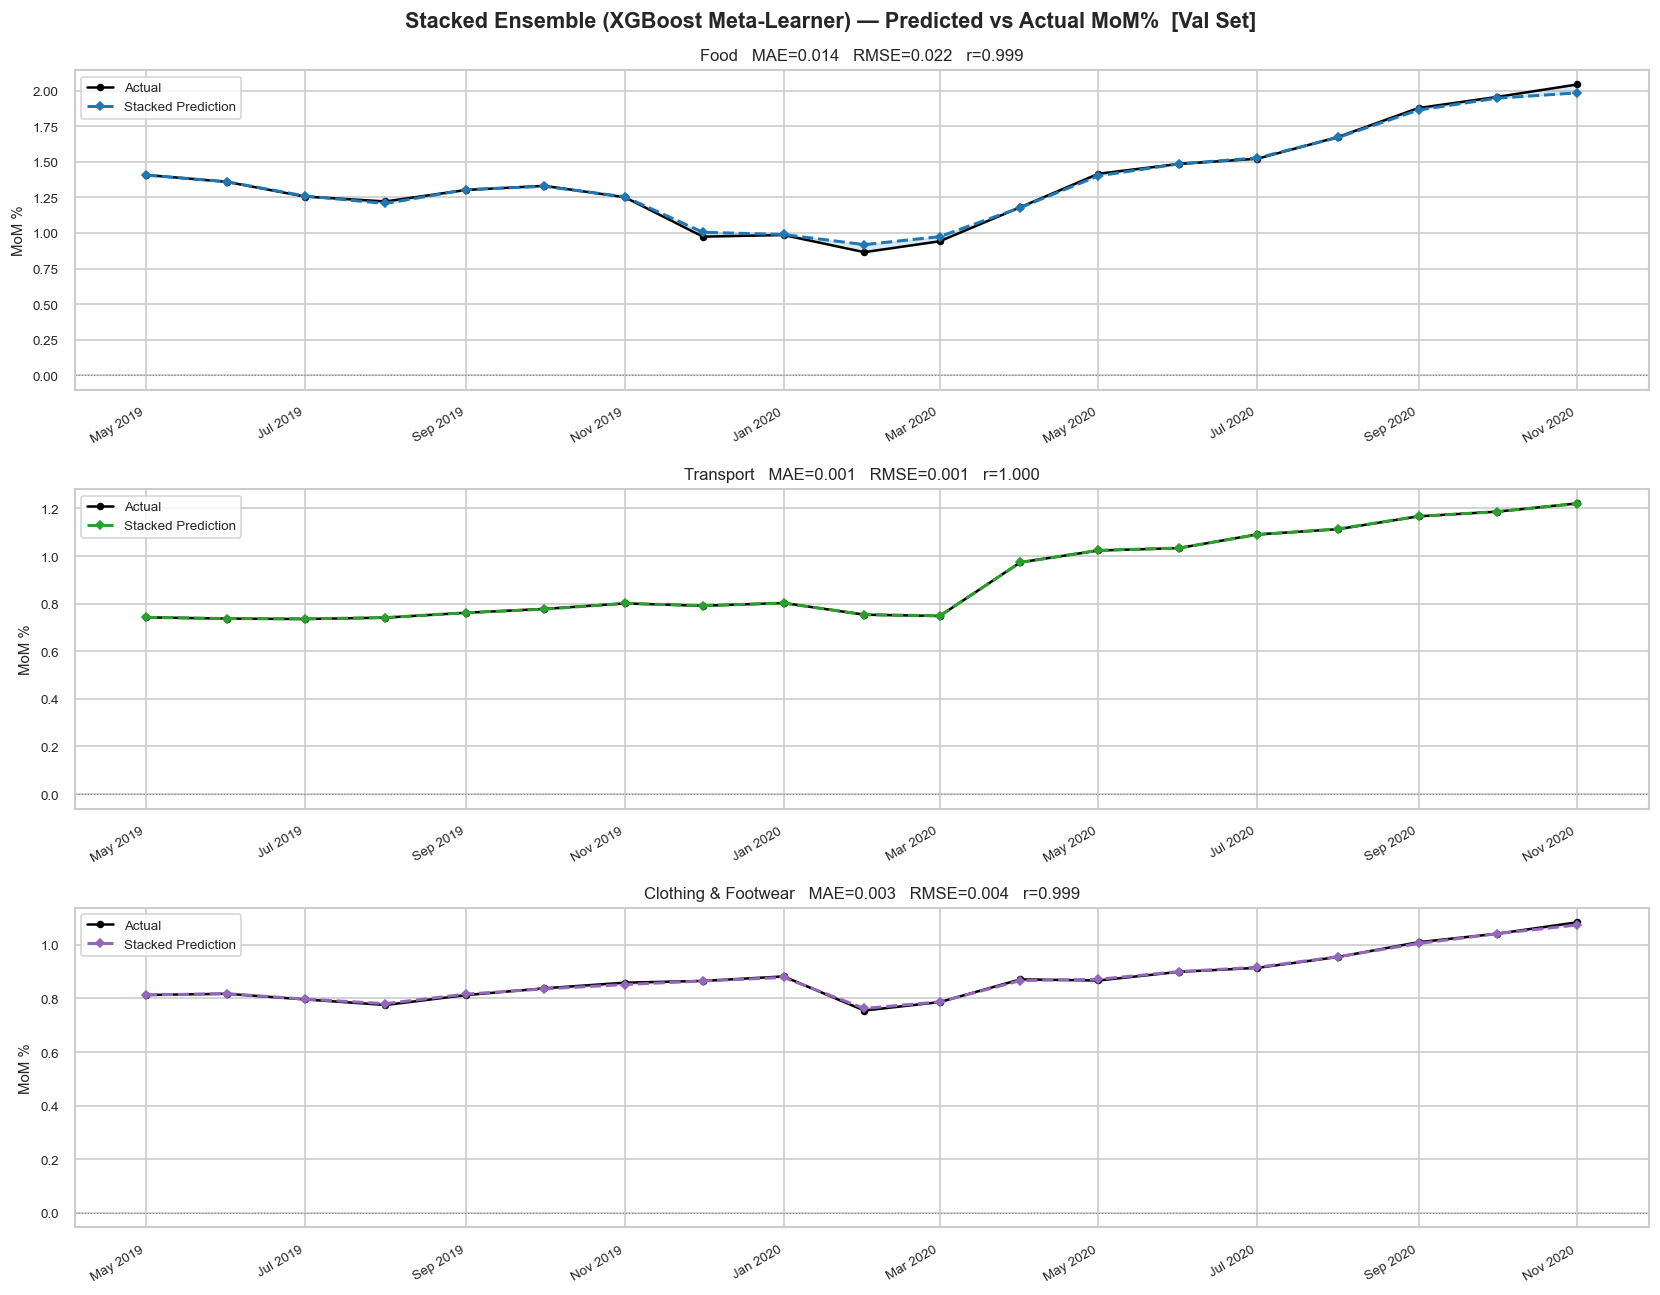

  Plot saved : ../outputs/stacked_pred_vs_actual_val.png
  CSV  saved : ../outputs/stacked_pred_vs_actual_val.csv


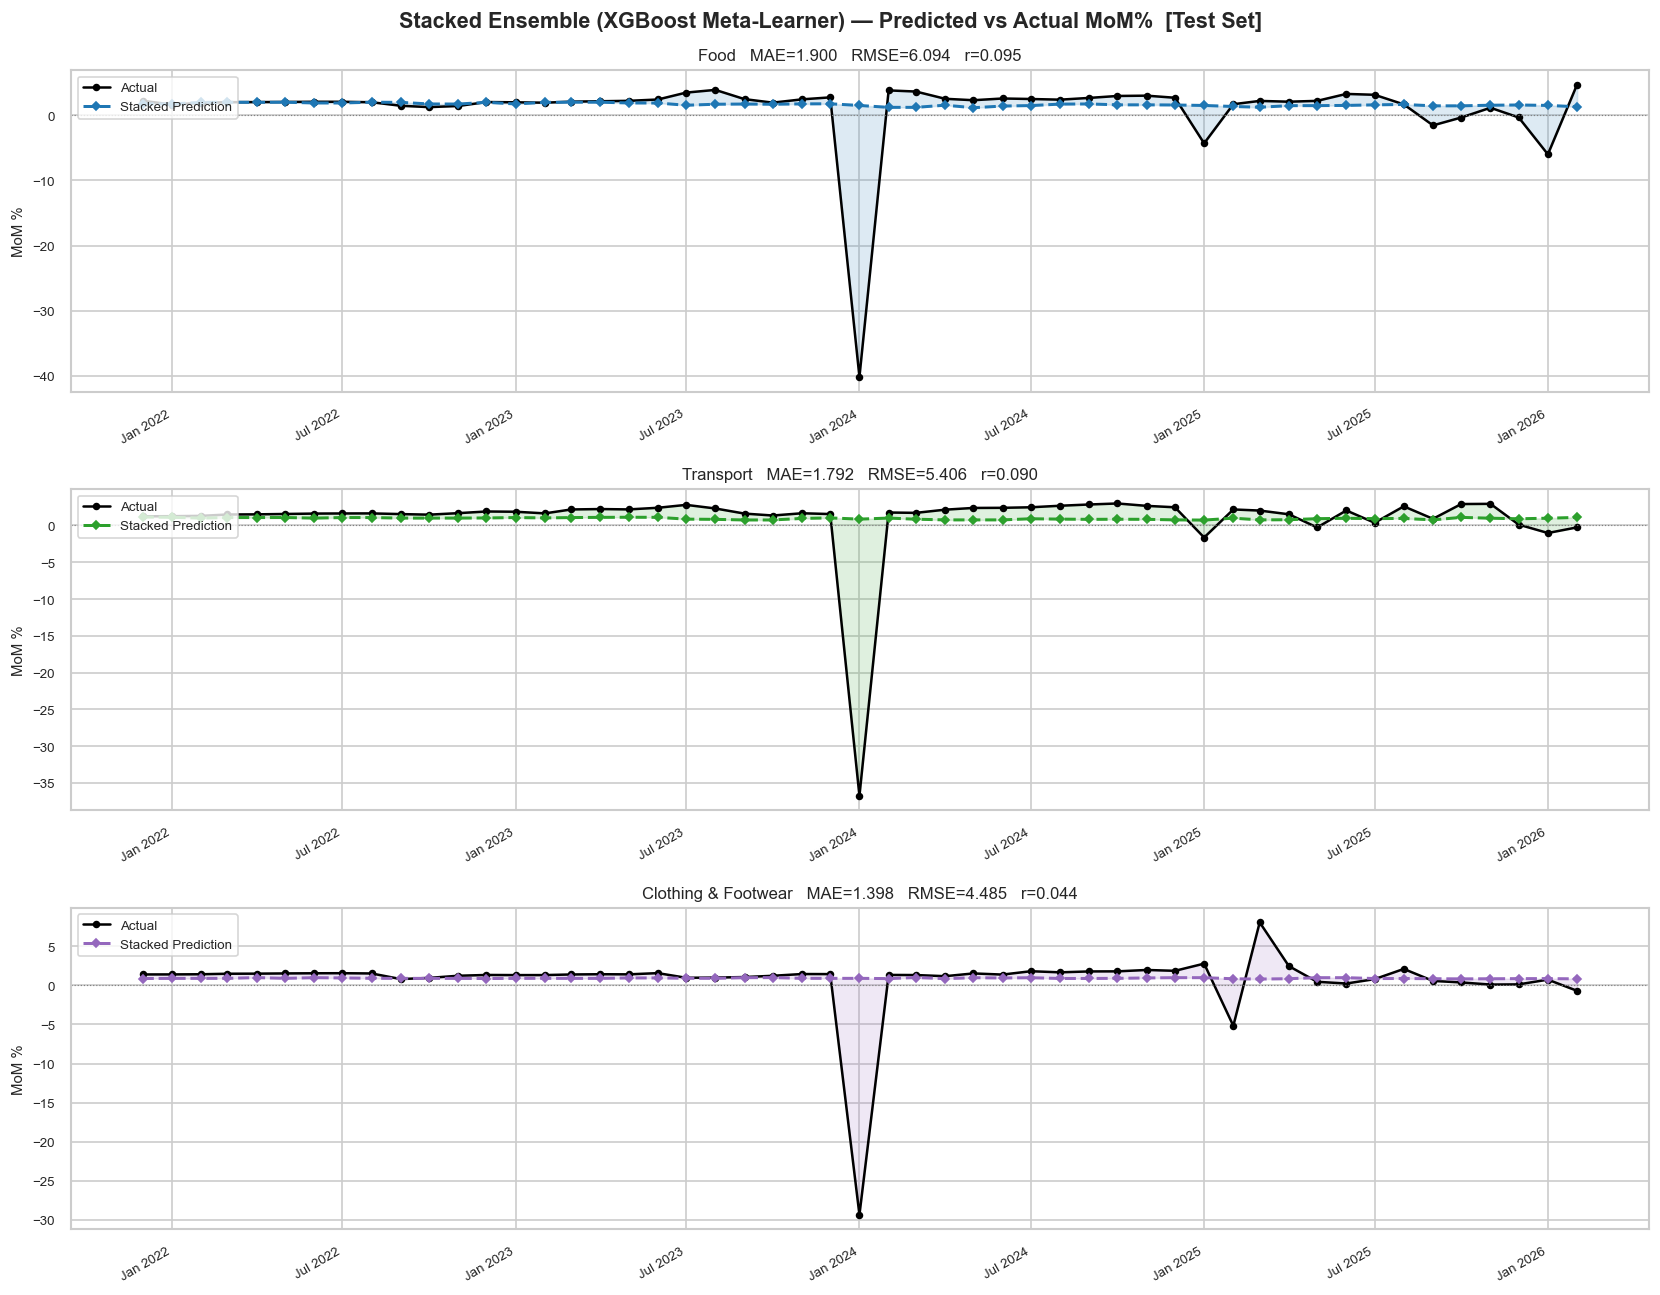

  Plot saved : ../outputs/stacked_pred_vs_actual_test.png
  CSV  saved : ../outputs/stacked_pred_vs_actual_test.csv

═════════════════════════════════════════════════════════════════
  OUTPUT 2 — Model Comparison (Test Set)
═════════════════════════════════════════════════════════════════
  Comparison CSV saved : ../outputs/model_comparison_test.csv

  Food:
  model    mae   rmse       r
SARIMAX 3.3019 7.7345  0.0710
     RF 2.0659 6.0913  0.0252
   LSTM 1.9531 6.1207 -0.0346
Stacked 1.9002 6.0936  0.0954

  Transport:
  model    mae   rmse      r
SARIMAX 3.6523 7.8176 0.0076
     RF 1.7824 5.4248 0.0023
   LSTM 1.7706 5.4138 0.0272
Stacked 1.7919 5.4059 0.0895

  Clothing & Footwear:
  model    mae   rmse       r
SARIMAX 3.0017 5.0465  0.1073
     RF 1.2974 4.4989  0.0493
   LSTM 1.3297 4.5147 -0.0466
Stacked 1.3981 4.4853  0.0444

  Best model per target (lowest MAE on test set):
    Food                     : Stacked    (MAE=1.9002)
    Transport                : LSTM       (MAE=1.7

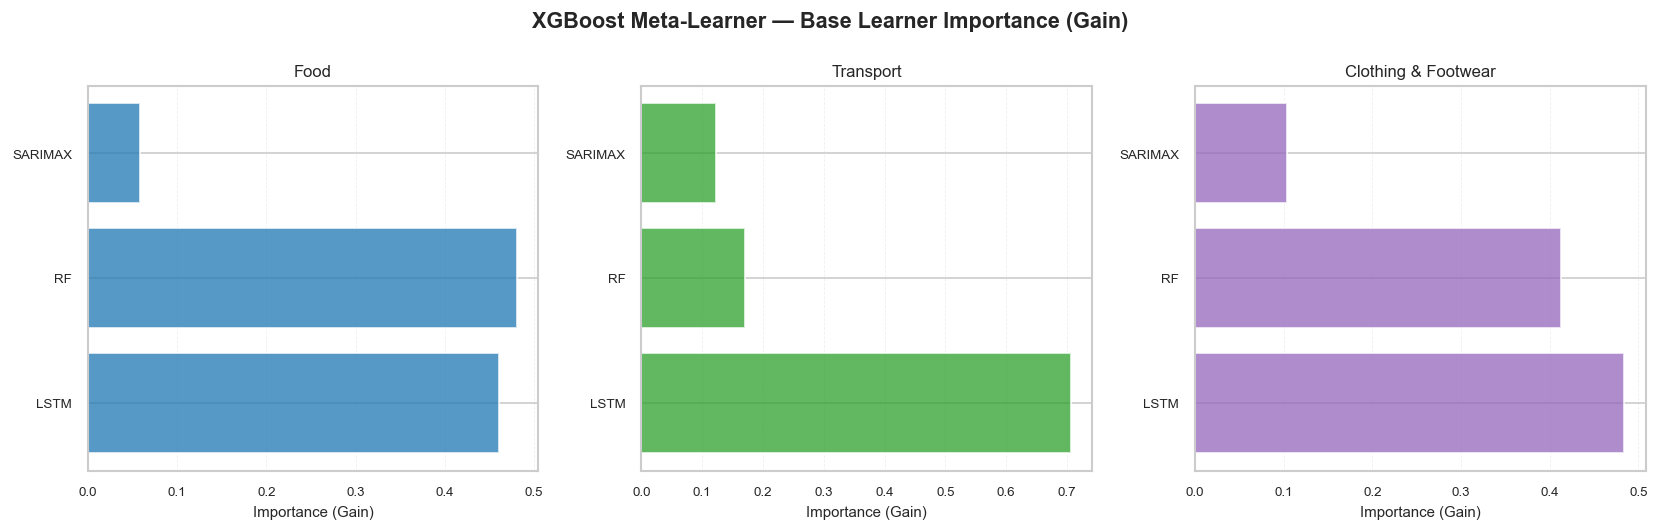

  Meta-feature importance plot saved : ../outputs/meta_feature_importance.png
  Meta-feature importance CSV saved  : ../outputs/meta_feature_importance.csv

  Food:
    RF         : 0.4808
    LSTM       : 0.4602
    SARIMAX    : 0.0590

  Transport:
    LSTM       : 0.7059
    RF         : 0.1707
    SARIMAX    : 0.1234

  Clothing & Footwear:
    LSTM       : 0.4839
    RF         : 0.4123
    SARIMAX    : 0.1039


═════════════════════════════════════════════════════════════════
  ✔  Stacked Ensemble complete.
  Meta-learners → ../models/meta_xgb_{{target}}.pkl  (x3)
  Outputs       → ../outputs/stacked_pred_vs_actual_val.csv/.png
                  ../outputs/stacked_pred_vs_actual_test.csv/.png
                  ../outputs/model_comparison_test.csv
                  ../outputs/meta_feature_importance.csv/.png
═════════════════════════════════════════════════════════════════


In [10]:
# ============================================================
# CELL 8 — XGBOOST META-LEARNER (STACKING)
# ============================================================
# Key design decisions:
#   • Meta-features: SARIMAX, RF, LSTM predictions on val set
#   • Meta-target: actual MoM on val set
#   • Grid search over max_depth, learning_rate, n_estimators
#   • Final test predictions use all 3 base learners refitted 
#     on train+val, then XGBoost meta-learner trained on val
#   • Outputs: meta-learner pkl, stacked predictions CSV + plot,
#     base learner comparison, meta-feature importance
# ============================================================

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../models',  exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

TARGET_NAMES  = ['food_mom', 'transport_mom', 'clothing_mom']
TARGET_LABELS = ['Food', 'Transport', 'Clothing & Footwear']
TARGET_COLORS = ['#1f77b4', '#2ca02c', '#9467bd']

meta_models      = {}
stacked_val_preds  = {}
stacked_test_preds = {}

print("═"*65)
print("  XGBOOST META-LEARNER — Stacking Architecture")
print("═"*65)

# ── Build meta-features (val set predictions from base learners)
print("\n  Building meta-features from base learner val predictions...")
print(f"    Val set size: {len(y_val)} observations")

for target, label in zip(TARGET_NAMES, TARGET_LABELS):

    print(f"\n  ▸ {label}")

    # ── Meta-features: base learner predictions on val ───────
    meta_X_val = pd.DataFrame({
        'sarimax_pred': sarimax_val_preds[target],
        'rf_pred'     : rf_val_preds[target],
        'lstm_pred'   : lstm_val_preds[target],
    })

    meta_y_val = y_val[target].values

    print(f"    Meta-features shape : {meta_X_val.shape}")
    print(f"    Meta-target shape   : {meta_y_val.shape}")

    # ── Grid search for meta-learner ──────────────────────────
    param_grid = {
        'max_depth'     : [3, 5, 7],
        'learning_rate' : [0.01, 0.05, 0.1],
        'n_estimators'  : [50, 100, 150],
        'subsample'     : [0.8],
        'colsample_bytree': [0.8],
    }

    base_xgb = xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )

    # TimeSeriesSplit with 2 splits (val is small, 19 obs)
    tscv = TimeSeriesSplit(n_splits=2)

    grid_search = GridSearchCV(
        estimator=base_xgb,
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(meta_X_val, meta_y_val)
    best_meta = grid_search.best_estimator_

    print(f"    Best meta-learner params:")
    for k, v in grid_search.best_params_.items():
        print(f"      {k:<18}: {v}")
    print(f"    Best CV MAE       : {-grid_search.best_score_:.4f}")

    meta_models[target] = best_meta

    # ── Save meta-learner ─────────────────────────────────────
    meta_path = f'../models/meta_xgb_{target}.pkl'
    with open(meta_path, 'wb') as f:
        pickle.dump(best_meta, f)
    print(f"    Meta-learner saved : {meta_path}")

    # ── Val stacked predictions (for diagnostics) ────────────
    stacked_val_preds[target] = best_meta.predict(meta_X_val)

    # ── Test stacked predictions ──────────────────────────────
    # Use base learner test predictions (already computed in Cells 5-7)
    meta_X_test = pd.DataFrame({
        'sarimax_pred': sarimax_test_preds[target],
        'rf_pred'     : rf_test_preds[target],
        'lstm_pred'   : lstm_test_preds[target],
    })

    stacked_test_preds[target] = best_meta.predict(meta_X_test)


# ════════════════════════════════════════════════════════════
# OUTPUT 1 — Stacked Predictions vs Actual (Val & Test)
# ════════════════════════════════════════════════════════════
print("\n\n" + "═"*65)
print("  OUTPUT 1 — Stacked Predictions vs Actual")
print("═"*65)

for split_name, split_df, y_split, preds_dict in [
    ('val',  val_df,  y_val,  stacked_val_preds),
    ('test', test_df, y_test, stacked_test_preds),
]:
    rows = []

    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)
    fig.suptitle(
        f'Stacked Ensemble (XGBoost Meta-Learner) — Predicted vs Actual MoM%  '
        f'[{split_name.capitalize()} Set]',
        fontweight='bold', fontsize=13
    )

    for ax, target, label, color in zip(axes, TARGET_NAMES, TARGET_LABELS, TARGET_COLORS):
        actual = y_split[target].values
        dates  = pd.to_datetime(split_df['date'].values)
        pred   = preds_dict[target]

        n = min(len(actual), len(pred), len(dates))
        actual, pred, dates = actual[:n], pred[:n], dates[:n]

        mae  = np.mean(np.abs(actual - pred))
        rmse = np.sqrt(np.mean((actual - pred) ** 2))
        corr = np.corrcoef(actual, pred)[0, 1] if n > 1 else np.nan

        ax.plot(dates, actual, color='black', linewidth=1.5,
                label='Actual',    marker='o', markersize=3.5)
        ax.plot(dates, pred,   color=color,  linewidth=1.8,
                label='Stacked Prediction', marker='D', markersize=3.5, linestyle='--')
        ax.fill_between(dates, actual, pred, alpha=0.15, color=color)
        ax.axhline(0, color='grey', linewidth=0.7, linestyle=':')
        ax.set_title(
            f'{label}   MAE={mae:.3f}   RMSE={rmse:.3f}   r={corr:.3f}',
            fontsize=10
        )
        ax.set_ylabel('MoM %')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
        ax.legend(loc='upper left', fontsize=8)

        for d, a, p_ in zip(dates, actual, pred):
            rows.append({
                'date'     : d.strftime('%Y-%m-%d'),
                'target'   : label,
                'actual'   : round(float(a),  4),
                'predicted': round(float(p_), 4),
                'error'    : round(float(a - p_), 4),
            })

    plt.tight_layout()
    plot_path = f'../outputs/stacked_pred_vs_actual_{split_name}.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Plot saved : {plot_path}")

    csv_path = f'../outputs/stacked_pred_vs_actual_{split_name}.csv'
    pd.DataFrame(rows).to_csv(csv_path, index=False)
    print(f"  CSV  saved : {csv_path}")


# ════════════════════════════════════════════════════════════
# OUTPUT 2 — Base Learner vs Stacked Comparison (Test Set)
# ════════════════════════════════════════════════════════════
print("\n" + "═"*65)
print("  OUTPUT 2 — Model Comparison (Test Set)")
print("═"*65)

comparison_rows = []

for target, label in zip(TARGET_NAMES, TARGET_LABELS):
    actual = y_test[target].values

    models_dict = {
        'SARIMAX'  : sarimax_test_preds[target],
        'RF'       : rf_test_preds[target],
        'LSTM'     : lstm_test_preds[target],
        'Stacked'  : stacked_test_preds[target],
    }

    for model_name, preds in models_dict.items():
        n = min(len(actual), len(preds))
        mae  = np.mean(np.abs(actual[:n] - preds[:n]))
        rmse = np.sqrt(np.mean((actual[:n] - preds[:n]) ** 2))
        r    = np.corrcoef(actual[:n], preds[:n])[0, 1]

        comparison_rows.append({
            'target'    : label,
            'model'     : model_name,
            'mae'       : round(mae,  4),
            'rmse'      : round(rmse, 4),
            'r'         : round(r,    4),
        })

comparison_df = pd.DataFrame(comparison_rows)
comp_csv_path = '../outputs/model_comparison_test.csv'
comparison_df.to_csv(comp_csv_path, index=False)
print(f"  Comparison CSV saved : {comp_csv_path}")
print()

# Print comparison table
for target_label in TARGET_LABELS:
    subset = comparison_df[comparison_df['target'] == target_label]
    print(f"  {target_label}:")
    print(subset[['model', 'mae', 'rmse', 'r']].to_string(index=False))
    print()

# Identify best model per target
print("  Best model per target (lowest MAE on test set):")
for target_label in TARGET_LABELS:
    subset = comparison_df[comparison_df['target'] == target_label]
    best_row = subset.loc[subset['mae'].idxmin()]
    print(f"    {target_label:<25}: {best_row['model']:<10} "
          f"(MAE={best_row['mae']:.4f})")


# ════════════════════════════════════════════════════════════
# OUTPUT 3 — Meta-Feature Importance
# ════════════════════════════════════════════════════════════
print("\n" + "═"*65)
print("  OUTPUT 3 — Meta-Feature Importance (Base Learner Weights)")
print("═"*65)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle('XGBoost Meta-Learner — Base Learner Importance (Gain)',
             fontweight='bold', fontsize=13)

imp_rows = []

for ax, target, label, color in zip(axes, TARGET_NAMES, TARGET_LABELS, TARGET_COLORS):
    meta = meta_models[target]
    importances = meta.feature_importances_
    feature_names = ['SARIMAX', 'RF', 'LSTM']

    ax.barh(feature_names, importances, color=color, alpha=0.75, edgecolor='white', linewidth=1.2)
    ax.set_xlabel('Importance (Gain)', fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)

    for name, imp in zip(feature_names, importances):
        imp_rows.append({
            'target'     : label,
            'base_learner': name,
            'importance' : round(imp, 4),
        })

plt.tight_layout()
imp_plot_path = '../outputs/meta_feature_importance.png'
plt.savefig(imp_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Meta-feature importance plot saved : {imp_plot_path}")

imp_csv_path = '../outputs/meta_feature_importance.csv'
pd.DataFrame(imp_rows).to_csv(imp_csv_path, index=False)
print(f"  Meta-feature importance CSV saved  : {imp_csv_path}")
print()

for target_label in TARGET_LABELS:
    print(f"  {target_label}:")
    subset = [r for r in imp_rows if r['target'] == target_label]
    for row in sorted(subset, key=lambda x: -x['importance']):
        print(f"    {row['base_learner']:<10} : {row['importance']:.4f}")
    print()


print("\n" + "═"*65)
print("  ✔  Stacked Ensemble complete.")
print("  Meta-learners → ../models/meta_xgb_{{target}}.pkl  (x3)")
print("  Outputs       → ../outputs/stacked_pred_vs_actual_val.csv/.png")
print("                  ../outputs/stacked_pred_vs_actual_test.csv/.png")
print("                  ../outputs/model_comparison_test.csv")
print("                  ../outputs/meta_feature_importance.csv/.png")
print("═"*65)